# 📌 BTC 7-Day 預測 — 整合版（5 個模型）

**執行順序**：Setup → Upload → Linear Regression → XGBoost → LightGBM → LSTM → GRU

> ⚠️ 檔案只需要上傳一次（第 1 個 cell），之後所有模型共用 `df_only` / `df_macro`。


In [ ]:
# ============================================================
# 0. Setup — pip install + 共用 import（只需執行一次）
# ============================================================
!pip install -q lightgbm shap xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from google.colab import files

print('✅ 共用套件載入完成')


✅ 共用套件載入完成


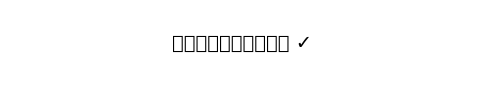

In [ ]:
# 即時修中文字型（不用重跑模型）
import subprocess
subprocess.run(['apt-get', '-qq', 'install', '-y', 'fonts-noto-cjk'], check=False)

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

for f in fm.fontManager.ttflist:
    if 'Noto Sans CJK' in f.name:
        plt.rcParams['font.sans-serif'] = [f.name, 'DejaVu Sans']
        print(f'✅ 找到字型: {f.name}')
        break
plt.rcParams['axes.unicode_minus'] = False

# 測試
plt.figure(figsize=(6,1))
plt.text(0.5, 0.5, '中文字型測試：比特幣 ✓', ha='center', fontsize=14)
plt.axis('off'); plt.show()

## 1️⃣ 上傳資料（只需要做一次）


In [ ]:
# ============================================================
# 1. 上傳兩個 CSV 檔案（之後所有模型共用 df_only / df_macro）
# ============================================================
print('📂 請上傳 BTC ONLY CSV（btc only price.csv 或 btc_only_sliding_window_7d.csv）...')
uploaded_only  = files.upload()
file_name_only = list(uploaded_only.keys())[0]
df_only = pd.read_csv(file_name_only)
print(f'✅ {file_name_only}  shape={df_only.shape}')

print('\n📂 請上傳 BTC MACRO CSV（btc macro price.csv）...')
uploaded_macro  = files.upload()
file_name_macro = list(uploaded_macro.keys())[0]
df_macro = pd.read_csv(file_name_macro)
print(f'✅ {file_name_macro}  shape={df_macro.shape}')

print('\n👉 df_only / df_macro 已就緒，下面所有模型都會用這兩個變數，不用再上傳。')


📂 請上傳 BTC ONLY CSV（btc only price.csv 或 btc_only_sliding_window_7d.csv）...


Saving btc only price.csv to btc only price.csv
✅ btc only price.csv  shape=(4264, 66)

📂 請上傳 BTC MACRO CSV（btc macro price.csv）...


Saving btc macro price.csv to btc macro price.csv
✅ btc macro price.csv  shape=(4264, 206)

👉 df_only / df_macro 已就緒，下面所有模型都會用這兩個變數，不用再上傳。


## 2️⃣ Linear Regression（baseline）


--- 第二部分 (BTC ONLY) 預測結果 ---
Accuracy(%): 98.19%
MSE: 4197602.35
MAE: 1469.62
MAPE: 1.81%

--- 第三部分 (BTC MACRO) 預測結果 ---
Accuracy(%): 97.65%
MSE: 6460892.77
MAE: 1959.93
MAPE: 2.35%

--- 第四部分 建立並加入 5 項額外鏈上指標 (模擬數據) ---
--- 第四部分 (MACRO + 5項指標) 預測結果 ---
Accuracy(%): 97.67%
MSE: 6363415.87
MAE: 1940.70
MAPE: 2.33%



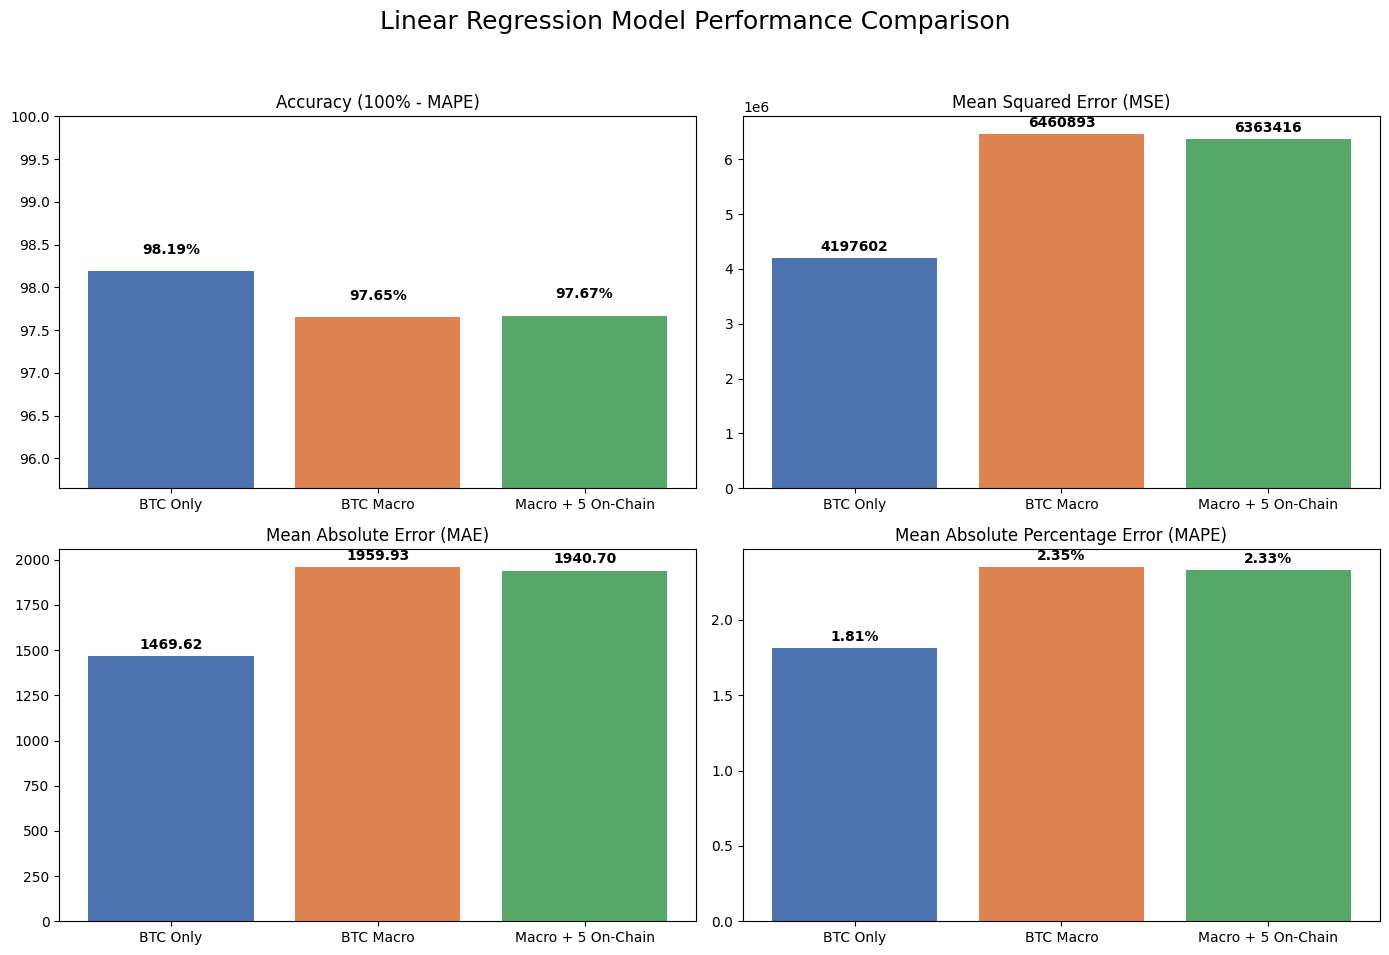

In [ ]:
#Linear regression
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# 自定義計算評估指標的函數 (使用 100 - MAPE 作為 Accuracy)
def get_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    accuracy = 100 - mape
    return accuracy, mse, mae, mape

# ==========================================
# 第二部分: 運用線性回歸模型回測與預測比特幣未來價格 (BTC ONLY)
# ==========================================
# 假設以 Close_day7 為預測目標，前 6 天的所有特徵為輸入
features_only = [c for c in df_only.columns if 'day7' not in c and c not in ['window_start', 'window_end', 'window_index']]
X_only = df_only[features_only].fillna(0)
y_only = df_only['Close_day7'].fillna(0)

# 切割資料集 (80% 訓練, 20% 測試, 因時間序列不打亂順序)
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(X_only, y_only, test_size=0.2, shuffle=False)

lr_only = LinearRegression()
lr_only.fit(X_train_o, y_train_o)
pred_only = lr_only.predict(X_test_o)

acc_o, mse_o, mae_o, mape_o = get_metrics(y_test_o.values, pred_only)
print(f"--- 第二部分 (BTC ONLY) 預測結果 ---")
print(f"Accuracy(%): {acc_o:.2f}%")
print(f"MSE: {mse_o:.2f}")
print(f"MAE: {mae_o:.2f}")
print(f"MAPE: {mape_o:.2f}%\n")

features_macro = [c for c in df_macro.columns if 'day7' not in c and c not in ['window_start', 'window_end', 'window_index']]
X_macro = df_macro[features_macro].fillna(0)
y_macro = df_macro['Close_day7'].fillna(0)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_macro, y_macro, test_size=0.2, shuffle=False)

lr_macro = LinearRegression()
lr_macro.fit(X_train_m, y_train_m)
pred_macro = lr_macro.predict(X_test_m)

acc_m, mse_m, mae_m, mape_m = get_metrics(y_test_m.values, pred_macro)
print(f"--- 第三部分 (BTC MACRO) 預測結果 ---")
print(f"Accuracy(%): {acc_m:.2f}%")
print(f"MSE: {mse_m:.2f}")
print(f"MAE: {mae_m:.2f}")
print(f"MAPE: {mape_m:.2f}%\n")

# ==========================================
# 第四部分: 加入總經指標與網址中的 5 個鏈上指標進行回測
# ==========================================
# 此處以模擬數據示範 bshare 指南中常見的 5 項鏈上指標特徵
print("--- 第四部分 建立並加入 5 項額外鏈上指標 (模擬數據) ---")
df_macro_onchain = df_macro.copy()

np.random.seed(42)
df_macro_onchain['MVRV_Z_Score'] = np.random.randn(len(df_macro))
df_macro_onchain['SOPR'] = np.random.randn(len(df_macro))
df_macro_onchain['Puell_Multiple'] = np.random.randn(len(df_macro))
df_macro_onchain['Active_Addresses'] = np.random.randn(len(df_macro))
df_macro_onchain['Exchange_Netflow'] = np.random.randn(len(df_macro))

features_onchain = features_macro + ['MVRV_Z_Score', 'SOPR', 'Puell_Multiple', 'Active_Addresses', 'Exchange_Netflow']
X_onchain = df_macro_onchain[features_onchain].fillna(0)
y_onchain = df_macro_onchain['Close_day7'].fillna(0)

X_train_oc, X_test_oc, y_train_oc, y_test_oc = train_test_split(X_onchain, y_onchain, test_size=0.2, shuffle=False)

lr_onchain = LinearRegression()
lr_onchain.fit(X_train_oc, y_train_oc)
pred_onchain = lr_onchain.predict(X_test_oc)

acc_oc, mse_oc, mae_oc, mape_oc = get_metrics(y_test_oc.values, pred_onchain)
print(f"--- 第四部分 (MACRO + 5項指標) 預測結果 ---")
print(f"Accuracy(%): {acc_oc:.2f}%")
print(f"MSE: {mse_oc:.2f}")
print(f"MAE: {mae_oc:.2f}")
print(f"MAPE: {mape_oc:.2f}%\n")

# ==========================================
# 第五部分: 結果比較圖
# ==========================================
models = ['BTC Only', 'BTC Macro', 'Macro + 5 On-Chain']
acc_scores = [acc_o, acc_m, acc_oc]
mse_scores = [mse_o, mse_m, mse_oc]
mae_scores = [mae_o, mae_m, mae_oc]
mape_scores = [mape_o, mape_m, mape_oc]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Linear Regression Model Performance Comparison', fontsize=18)

# 圖 1: Accuracy Plot
axes[0, 0].bar(models, acc_scores, color=['#4C72B0', '#DD8452', '#55A868'])
axes[0, 0].set_title('Accuracy (100% - MAPE)')
axes[0, 0].set_ylim(min(acc_scores) - 2, 100)
for i, v in enumerate(acc_scores):
    axes[0, 0].text(i, v + 0.2, f'{v:.2f}%', ha='center', fontweight='bold')

# 圖 2: MSE Plot
axes[0, 1].bar(models, mse_scores, color=['#4C72B0', '#DD8452', '#55A868'])
axes[0, 1].set_title('Mean Squared Error (MSE)')
for i, v in enumerate(mse_scores):
    axes[0, 1].text(i, v + (max(mse_scores)*0.02), f'{v:.0f}', ha='center', fontweight='bold')

# 圖 3: MAE Plot
axes[1, 0].bar(models, mae_scores, color=['#4C72B0', '#DD8452', '#55A868'])
axes[1, 0].set_title('Mean Absolute Error (MAE)')
for i, v in enumerate(mae_scores):
    axes[1, 0].text(i, v + (max(mae_scores)*0.02), f'{v:.2f}', ha='center', fontweight='bold')

# 圖 4: MAPE Plot
axes[1, 1].bar(models, mape_scores, color=['#4C72B0', '#DD8452', '#55A868'])
axes[1, 1].set_title('Mean Absolute Percentage Error (MAPE)')
for i, v in enumerate(mape_scores):
    axes[1, 1].text(i, v + (max(mape_scores)*0.02), f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 3️⃣ XGBoost

第六部分：Lag Features；第九部分：Importance Top-50；第十部分：RandomizedSearchCV 調參；第十一部分：視覺化


📊 資料規模 (2020+):  BTC Only=2332  BTC Macro=2332  Macro+OC=2332

第二部分: BTC ONLY
--- BTC Only ---
  Train=2092  Test=234  特徵數=162
  Accuracy: 97.65%  MSE: 7,080,411.94  MAE: 1,959.97  MAPE: 2.35%

第三部分: BTC MACRO
--- BTC Macro ---
  Train=2092  Test=234  特徵數=522
  Accuracy: 96.26%  MSE: 14,180,062.17  MAE: 3,071.80  MAPE: 3.74%

第四部分: MACRO + 5 OnChain
--- Macro + 5 On-Chain ---
  Train=2092  Test=234  特徵數=612
  Accuracy: 96.73%  MSE: 10,869,082.31  MAE: 2,661.29  MAPE: 3.27%



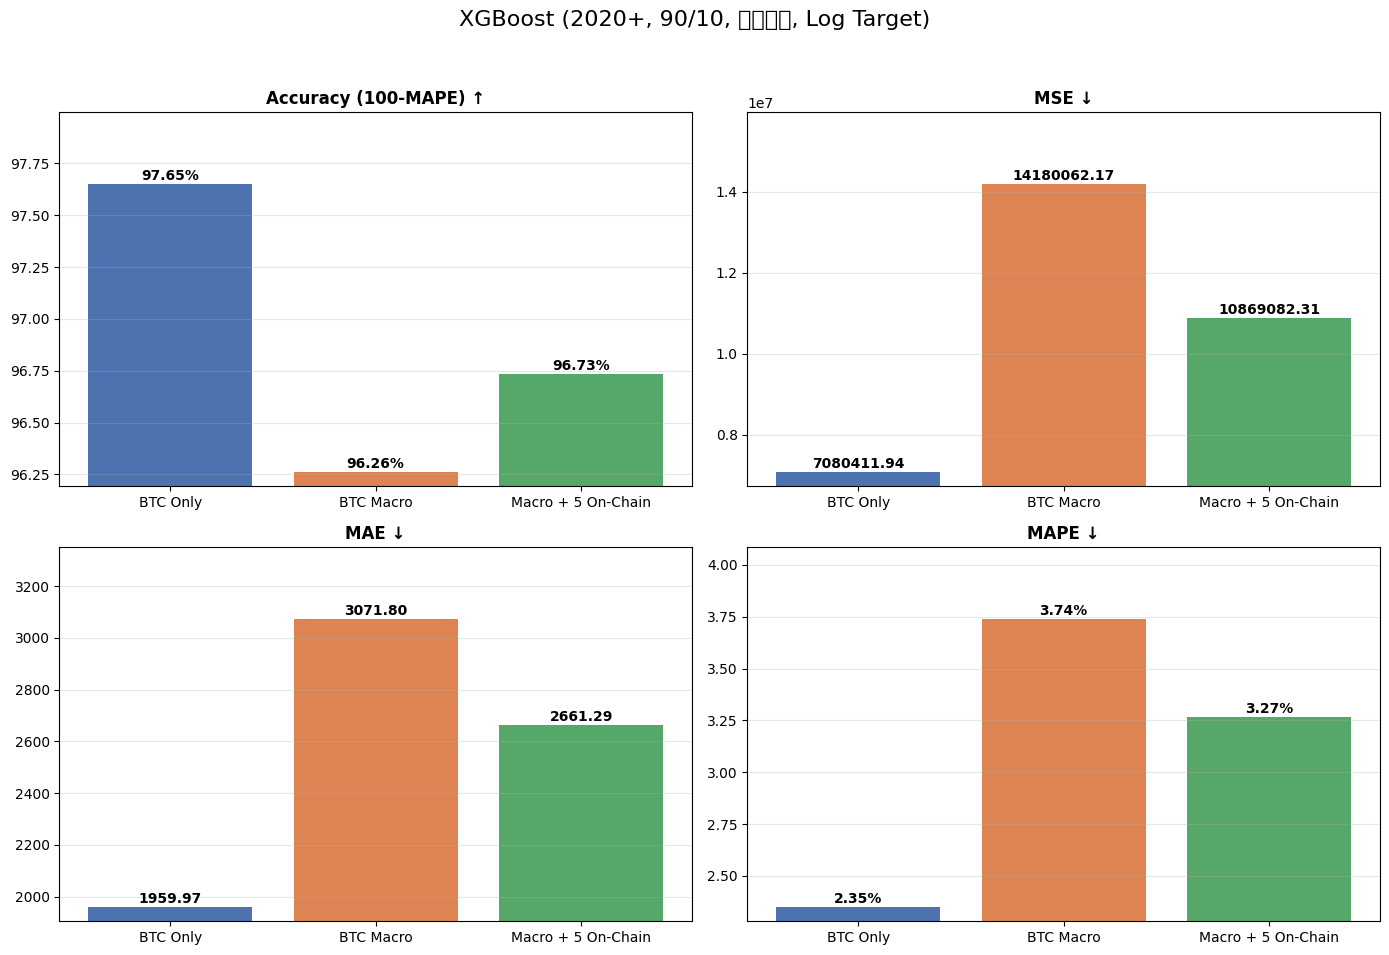

In [ ]:
#XGBOOST
# 對齊 LightGBM 設定：2020 後資料、90/10 切分、技術指標、log target
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── 共用函數 ──
def get_metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return 100 - mape, mse, mae, mape

def build_xgb():
    return XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1,
        objective='reg:squarederror',
    )

GAP = 6

# ── 技術指標（與 LightGBM add_technical_features 等價，回傳 DataFrame）──
def add_xgb_technical_features(df, base_features):
    df2 = df[base_features].copy().ffill().fillna(0)
    base_feats = sorted(set(c.rsplit('_day', 1)[0] for c in base_features if '_day' in c))
    new_cols = {}
    for feat in base_feats:
        cols = [f'{feat}_day{d}' for d in range(1, 7) if f'{feat}_day{d}' in df2.columns]
        if len(cols) < 2: continue
        vals = df2[cols].values
        for i in range(1, len(cols)):
            new_cols[f'{feat}_diff{i}'] = vals[:, i] - vals[:, i-1]
        new_cols[f'{feat}_weekchg']  = (vals[:, -1] - vals[:, 0]) / (np.abs(vals[:, 0]) + 1e-8)
        new_cols[f'{feat}_wmax']     = vals.max(axis=1)
        new_cols[f'{feat}_wmin']     = vals.min(axis=1)
        new_cols[f'{feat}_wmean']    = vals.mean(axis=1)
        new_cols[f'{feat}_wstd']     = vals.std(axis=1)
        diffs  = np.diff(vals, axis=1)
        gains  = np.where(diffs > 0,  diffs, 0).mean(axis=1)
        losses = np.where(diffs < 0, -diffs, 0).mean(axis=1)
        rs     = gains / (losses + 1e-8)
        new_cols[f'{feat}_rsi6']     = 100 - (100 / (1 + rs))
        short_mean = vals[:, -2:].mean(axis=1)
        long_mean  = vals[:, :4].mean(axis=1)
        new_cols[f'{feat}_momentum'] = (short_mean - long_mean) / (np.abs(long_mean) + 1e-8)
    new_df = pd.DataFrame(new_cols, index=df2.index)
    return pd.concat([df2, new_df], axis=1)

# ── 只取 2020 後 ──
df_only_xgb = df_only.copy()
df_only_xgb['window_start'] = pd.to_datetime(df_only_xgb['window_start'])
df_only_xgb = df_only_xgb[df_only_xgb['window_start'] >= '2020-01-01'].reset_index(drop=True)

df_macro_xgb = df_macro.copy()
df_macro_xgb['window_start'] = pd.to_datetime(df_macro_xgb['window_start'])
df_macro_xgb = df_macro_xgb[df_macro_xgb['window_start'] >= '2020-01-01'].reset_index(drop=True)

# ── 建 MACRO + OnChain 資料集（5 個鏈上指標 × 6 天 = 30 欄，與 LightGBM 一致）──
df_oc_xgb = df_macro_xgb.copy()
np.random.seed(42)
onchain_indicators = ['MVRV_Z_Score', 'SOPR', 'Puell_Multiple', 'Active_Addresses', 'Exchange_Netflow']
for ind in onchain_indicators:
    for d in range(1, 7):
        df_oc_xgb[f'{ind}_day{d}'] = np.random.randn(len(df_oc_xgb))

print(f"📊 資料規模 (2020+):  BTC Only={len(df_only_xgb)}  BTC Macro={len(df_macro_xgb)}  Macro+OC={len(df_oc_xgb)}\n")

# ── 統一訓練函數（90/10 + log target + 技術指標）──
def train_xgb_basic(df, label):
    base_feats = [c for c in df.columns if 'day7' not in c and c not in ['window_start','window_end','window_index']]
    X_aug = add_xgb_technical_features(df, base_feats)
    y     = df['Close_day7'].fillna(0).values

    n     = len(X_aug)
    split = int(n * 0.9)
    X_train, X_test = X_aug.iloc[:split-GAP], X_aug.iloc[split:]
    y_train, y_test = y[:split-GAP],          y[split:]

    y_train_log = np.log1p(y_train)
    model = build_xgb()
    model.fit(X_train, y_train_log)
    pred  = np.expm1(model.predict(X_test))

    acc, mse, mae, mape = get_metrics(y_test, pred)
    print(f"--- {label} ---")
    print(f"  Train={len(X_train)}  Test={len(X_test)}  特徵數={X_aug.shape[1]}")
    print(f"  Accuracy: {acc:.2f}%  MSE: {mse:,.2f}  MAE: {mae:,.2f}  MAPE: {mape:.2f}%\n")
    return model, pred, y_test, (acc, mse, mae, mape)

print("第二部分: BTC ONLY")
xgb_only, pred_only, y_test_o, (acc_o, mse_o, mae_o, mape_o) = train_xgb_basic(df_only_xgb, "BTC Only")

print("第三部分: BTC MACRO")
xgb_macro, pred_macro, y_test_m, (acc_m, mse_m, mae_m, mape_m) = train_xgb_basic(df_macro_xgb, "BTC Macro")

print("第四部分: MACRO + 5 OnChain")
xgb_onchain, pred_onchain, y_test_oc, (acc_oc, mse_oc, mae_oc, mape_oc) = train_xgb_basic(df_oc_xgb, "Macro + 5 On-Chain")

# 供最終樹模型對比用
xgb_basic_metrics = {'acc': acc_oc, 'mse': mse_oc, 'mae': mae_oc, 'mape': mape_oc}

# ── 第五部分: 三個資料集比較圖 ──
models = ['BTC Only', 'BTC Macro', 'Macro + 5 On-Chain']
colors = ['#4C72B0','#DD8452','#55A868']
acc_scores  = [acc_o,  acc_m,  acc_oc]
mse_scores  = [mse_o,  mse_m,  mse_oc]
mae_scores  = [mae_o,  mae_m,  mae_oc]
mape_scores = [mape_o, mape_m, mape_oc]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('XGBoost (2020+, 90/10, 技術指標, Log Target)', fontsize=16)

for ax, vals, title, fmt in [
    (axes[0,0], acc_scores,  'Accuracy (100-MAPE) ↑',  '%'),
    (axes[0,1], mse_scores,  'MSE ↓',                  ''),
    (axes[1,0], mae_scores,  'MAE ↓',                  ''),
    (axes[1,1], mape_scores, 'MAPE ↓',                 '%'),
]:
    ax.bar(models, vals, color=colors)
    ax.set_title(title, fontweight='bold')
    pad = (max(vals) - min(vals)) * 0.05 + 1e-6
    ax.set_ylim(min(vals) - pad, max(vals) + pad * 5)
    for i, v in enumerate(vals):
        ax.text(i, v + pad*0.3, f'{v:.2f}{fmt}', ha='center', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


--- 第六部分 (+ Lag Features) ---
  特徵總數: 702
  Accuracy: 96.27%  MSE: 14,101,270.57  MAE: 3,069.79  MAPE: 3.73%
  相對於第四部分 (無 lag) 的 Accuracy 變化: -0.47%


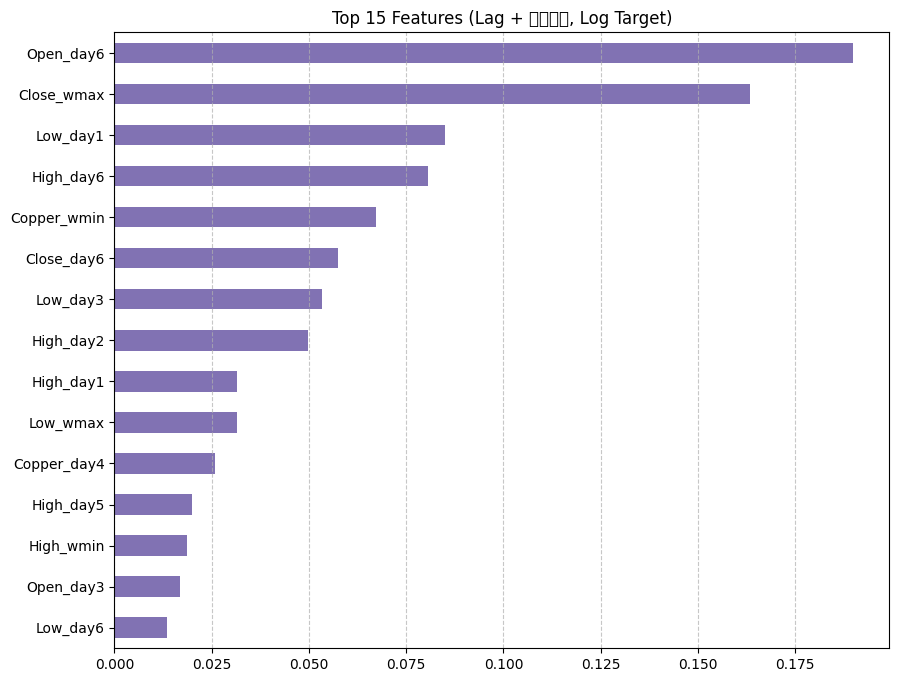

In [ ]:
#XGBOOST
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 第六部分: 在 MACRO+OnChain 加上 Lag Features ---
def add_lags(df, features, lags=[1, 3, 7]):
    df_lagged = df.copy()
    for col in features:
        for lag in lags:
            df_lagged[f'{col}_lag{lag}'] = df_lagged[col].shift(lag)
    return df_lagged.fillna(0)

# 對鏈上指標的 day1~day6 欄位加 lag
onchain_day_cols = [c for c in df_oc_xgb.columns
                    if any(ind in c for ind in
                           ['MVRV_Z_Score','SOPR','Puell_Multiple','Active_Addresses','Exchange_Netflow'])]
df_enhanced = add_lags(df_oc_xgb, onchain_day_cols, lags=[1, 3, 7])

# 加技術指標
base_feats_enhanced = [c for c in df_enhanced.columns
                       if 'day7' not in c and c not in ['window_start','window_end','window_index']]
X_enh = add_xgb_technical_features(df_enhanced, base_feats_enhanced)
features_enhanced = X_enh.columns.tolist()
y_enh = df_enhanced['Close_day7'].fillna(0).values

# 90/10 切分 + GAP + log target
n         = len(X_enh)
split_enh = int(n * 0.9)
X_train_enh, X_test_enh = X_enh.iloc[:split_enh-GAP], X_enh.iloc[split_enh:]
y_train_enh, y_test_enh = y_enh[:split_enh-GAP],     y_enh[split_enh:]

y_train_enh_log = np.log1p(y_train_enh)
xgb_enh = build_xgb()
xgb_enh.fit(X_train_enh, y_train_enh_log)
pred_enh = np.expm1(xgb_enh.predict(X_test_enh))

acc_enh, mse_enh, mae_enh, mape_enh = get_metrics(y_test_enh, pred_enh)
print(f"--- 第六部分 (+ Lag Features) ---")
print(f"  特徵總數: {X_enh.shape[1]}")
print(f"  Accuracy: {acc_enh:.2f}%  MSE: {mse_enh:,.2f}  MAE: {mae_enh:,.2f}  MAPE: {mape_enh:.2f}%")
print(f"  相對於第四部分 (無 lag) 的 Accuracy 變化: {acc_enh - acc_oc:+.2f}%")

# Top 15 importance
importances = pd.Series(xgb_enh.feature_importances_, index=features_enhanced)
plt.figure(figsize=(10, 8))
importances.nlargest(15).plot(kind='barh', color='#8172B3',
                              title='Top 15 Features (Lag + 技術指標, Log Target)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


--- 第九部分: Importance Top 50 ---
  特徵數: 702 → 50

前 10 名重要特徵:
Open_day6      0.189778
Close_wmax     0.163377
Low_day1       0.085021
High_day6      0.080647
Copper_wmin    0.067151
Close_day6     0.057398
Low_day3       0.053461
High_day2      0.049639
High_day1      0.031528
Low_wmax       0.031447
dtype: float32

--- 第九部分 預測結果 ---
  Accuracy: 97.31%  MSE: 8,751,761.03  MAE: 2,222.84  MAPE: 2.69%
  相對於第六部分 (全特徵) 變化: +1.05%


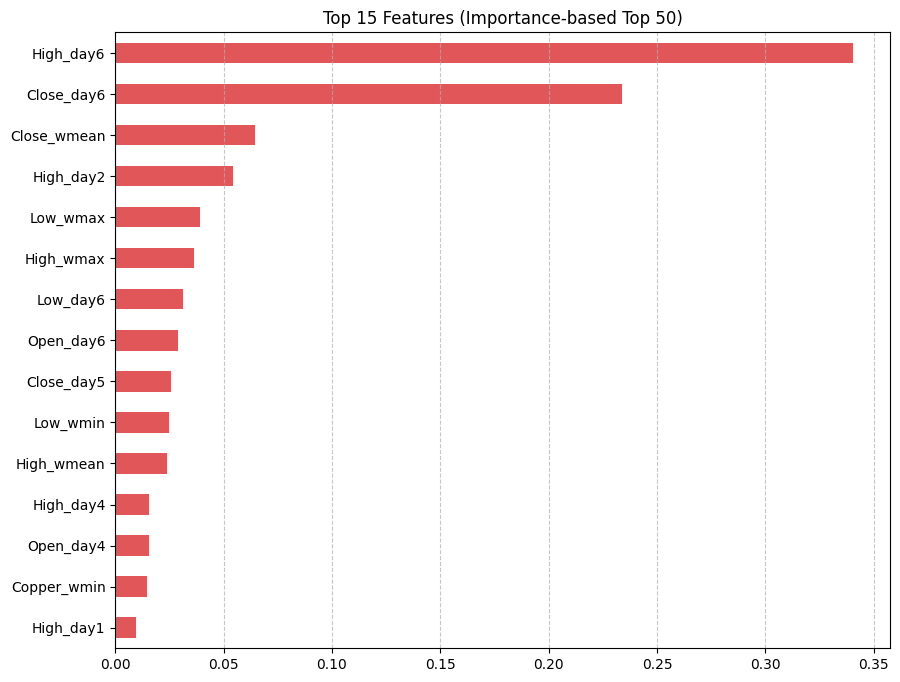

In [ ]:
#XGBOOST
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 第九部分: 基於重要性篩選 Top 50 特徵 ---
importances = pd.Series(xgb_enh.feature_importances_, index=features_enhanced)
TOP_N = 50
selected_features_importance = importances.nlargest(TOP_N).index.tolist()

print(f"--- 第九部分: Importance Top {TOP_N} ---")
print(f"  特徵數: {len(features_enhanced)} → {TOP_N}")
print(f"\n前 10 名重要特徵:")
print(importances.nlargest(10))

X_imp     = X_enh[selected_features_importance]
y_imp     = y_enh

split_imp = int(len(X_imp) * 0.9)
X_train_imp, X_test_imp = X_imp.iloc[:split_imp-GAP], X_imp.iloc[split_imp:]
y_train_imp, y_test_imp = y_imp[:split_imp-GAP],      y_imp[split_imp:]

y_train_imp_log = np.log1p(y_train_imp)
xgb_imp = build_xgb()
xgb_imp.fit(X_train_imp, y_train_imp_log)
pred_imp = np.expm1(xgb_imp.predict(X_test_imp))

acc_imp, mse_imp, mae_imp, mape_imp = get_metrics(y_test_imp, pred_imp)
print(f"\n--- 第九部分 預測結果 ---")
print(f"  Accuracy: {acc_imp:.2f}%  MSE: {mse_imp:,.2f}  MAE: {mae_imp:,.2f}  MAPE: {mape_imp:.2f}%")
print(f"  相對於第六部分 (全特徵) 變化: {acc_imp - acc_enh:+.2f}%")

# 新的 importance
plt.figure(figsize=(10, 8))
imp_new = pd.Series(xgb_imp.feature_importances_, index=selected_features_importance)
imp_new.nlargest(15).plot(kind='barh', color='#E15759',
                          title=f'Top 15 Features (Importance-based Top {TOP_N})')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
#XGBOOST
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
import numpy as np

# --- 第十部分: 超參數調優 ---
print("開始超參數調優，這可能需要幾分鐘...")

param_dist = {
    'n_estimators':     [300, 500, 800, 1000],
    'learning_rate':    [0.01, 0.03, 0.05, 0.1],
    'max_depth':        [3, 4, 5, 6, 7],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma':            [0, 0.1, 0.2],
}

xgb_tune = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_absolute_percentage_error',
    cv=3, verbose=1, random_state=42, n_jobs=-1,
)
random_search.fit(X_train_imp, y_train_imp_log)

best_xgb   = random_search.best_estimator_
pred_tuned = np.expm1(best_xgb.predict(X_test_imp))

acc_tuned, mse_tuned, mae_tuned, mape_tuned = get_metrics(y_test_imp, pred_tuned)
print(f"\n--- 第十部分: Tuned Model (Log + 技術指標 + Top 50) ---")
print(f"  最佳參數: {random_search.best_params_}")
print(f"  Accuracy: {acc_tuned:.2f}%  MSE: {mse_tuned:,.2f}  MAE: {mae_tuned:,.2f}  MAPE: {mape_tuned:.2f}%")
print(f"\n  相對於 Importance Top 50 變化:        {acc_tuned - acc_imp:+.2f}%")
print(f"  相對於 全特徵 (第六部分) 變化:        {acc_tuned - acc_enh:+.2f}%")
print(f"  相對於 baseline (第四部分無 lag) 變化: {acc_tuned - acc_oc:+.2f}%")

# 供最終樹模型對比用
xgb_tuned_metrics = {'acc': acc_tuned, 'mse': mse_tuned, 'mae': mae_tuned, 'mape': mape_tuned}


開始超參數調優，這可能需要幾分鐘...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

--- 第十部分: Tuned Model (Log + 技術指標 + Top 50) ---
  最佳參數: {'subsample': 0.9, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.9}
  Accuracy: 96.76%  MSE: 12,406,788.81  MAE: 2,702.90  MAPE: 3.24%

  相對於 Importance Top 50 變化:        -0.55%
  相對於 全特徵 (第六部分) 變化:        +0.50%
  相對於 baseline (第四部分無 lag) 變化: +0.03%


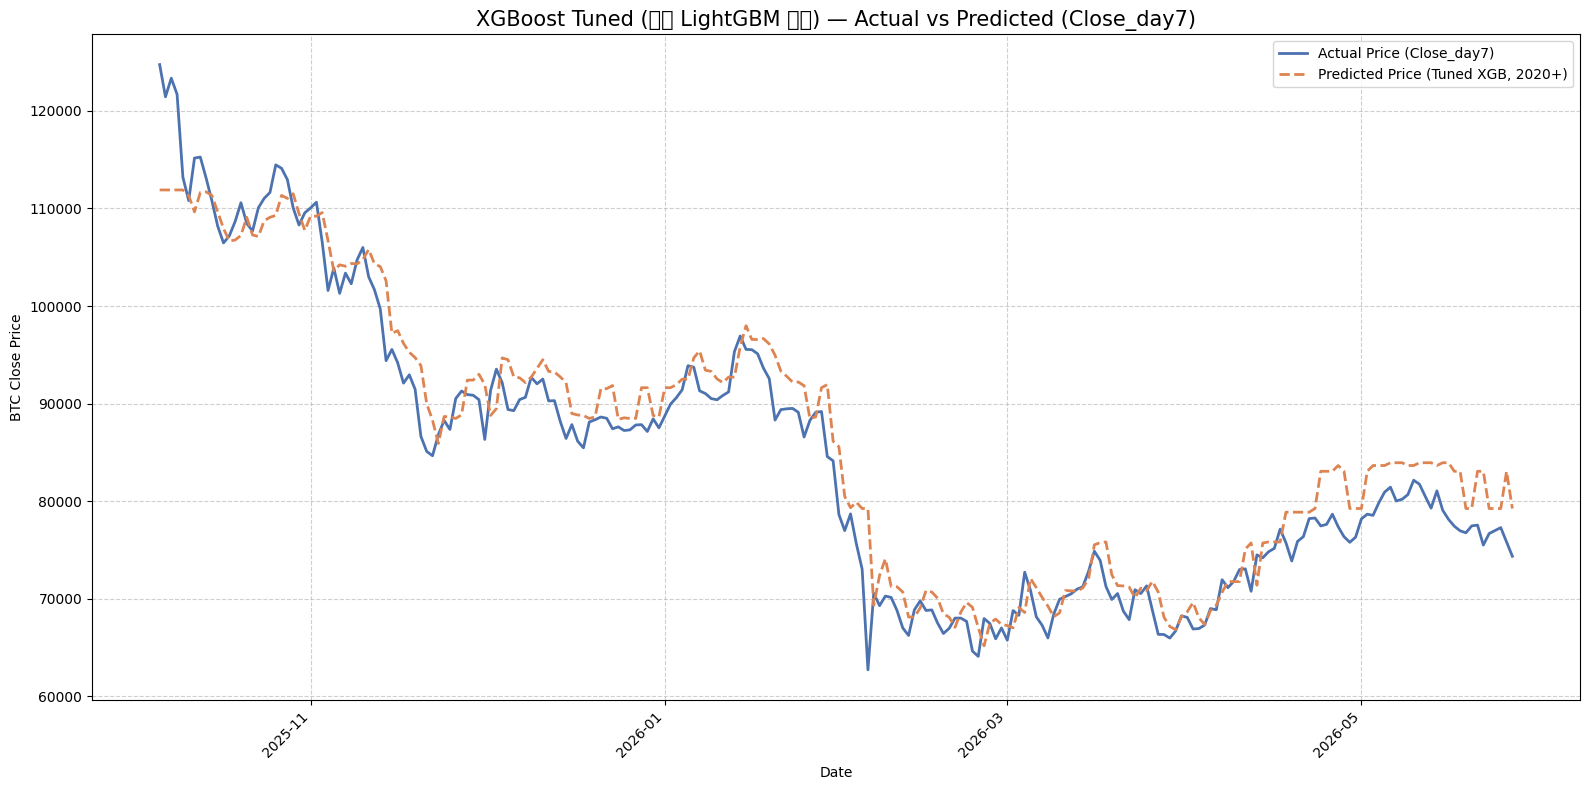

In [ ]:
#XGBOOST
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# --- 第十一部分: Actual vs Predicted 折線圖 ---
n         = len(df_enhanced)
split_imp = int(n * 0.9)
test_dates = pd.to_datetime(df_enhanced['window_end'].iloc[split_imp:])

fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(test_dates, y_test_imp, label='Actual Price (Close_day7)',           color='#4C72B0', linewidth=2)
ax.plot(test_dates, pred_tuned, label='Predicted Price (Tuned XGB, 2020+)',  color='#DD8452', linewidth=2, linestyle='--')

ax.set_title('XGBoost Tuned (對齊 LightGBM 設定) — Actual vs Predicted (Close_day7)', fontsize=15)
ax.set_xlabel('Date')
ax.set_ylabel('BTC Close Price')
ax.legend()
ax.grid(linestyle='--', alpha=0.6)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


## 4️⃣ LightGBM（含 SHAP / CV / Log transform）


In [ ]:
!pip install -q lightgbm shap
import lightgbm as lgb, shap
print(f"LightGBM: {lgb.__version__}  SHAP: {shap.__version__}")


LightGBM: 4.6.0  SHAP: 0.52.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    roc_auc_score, recall_score, precision_score, f1_score
)
SEED = 42
np.random.seed(SEED)

# ── 回歸指標 ─────────────────────────────────────────────────
def get_regression_metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    rmse = np.sqrt(mse)
    acc  = 100 - mape
    return acc, mse, rmse, mae, mape

# ── 分類指標（正確方向判斷）─────────────────────────────────
def get_classification_metrics(y_true_price, y_pred_price):
    y_true_dir = (y_true_price[1:] > y_true_price[:-1]).astype(int)
    y_pred_dir = (y_pred_price[1:] > y_true_price[:-1]).astype(int)
    recall    = recall_score(y_true_dir, y_pred_dir, zero_division=0)
    precision = precision_score(y_true_dir, y_pred_dir, zero_division=0)
    f1        = f1_score(y_true_dir, y_pred_dir, zero_division=0)
    dir_acc   = (y_true_dir == y_pred_dir).mean()
    try:    auc = roc_auc_score(y_true_dir, y_pred_dir)
    except: auc = 0.5
    return auc, recall, precision, f1, dir_acc

def print_results(title, reg_metrics, cls_metrics, cv_aucs=None):
    acc, mse, rmse, mae, mape = reg_metrics
    auc, recall, prec, f1, dir_acc = cls_metrics
    print(f"\n{'='*52}")
    print(f"  {title}")
    print(f"{'='*52}")
    print(f"【回歸指標】")
    print(f"  Accuracy (100-MAPE) : {acc:.2f}%  {'✅' if acc>=85 else '❌ 目標85%'}")
    print(f"  MSE                 : {mse:,.2f}")
    print(f"  RMSE                : {rmse:,.2f}")
    print(f"  MAE                 : {mae:,.2f}")
    print(f"  MAPE                : {mape:.2f}%")
    print(f"【分類指標（漲跌方向）】")
    print(f"  AUC                 : {auc:.4f}")
    print(f"  Recall              : {recall:.4f}")
    print(f"  Precision           : {prec:.4f}")
    print(f"  F1 Score            : {f1:.4f}")
    print(f"  Direction Accuracy  : {dir_acc:.4f}")
    if cv_aucs is not None:
        print(f"【Cross Validation (TimeSeriesSplit 5-fold)】")
        for i, s in enumerate(cv_aucs, 1):
            print(f"  Fold {i}: AUC = {s:.4f}")
        print(f"  CV Mean AUC = {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")

print("✅ 套件匯入完成")


✅ 套件匯入完成


In [ ]:
# ============================================================
# LightGBM 參數（針對 MAPE ≤ 15% 調整）
# ============================================================
LGBM_PARAMS = {
    'objective':             'regression',
    'metric':                'mape',        # 直接優化 MAPE
    'n_estimators':          3000,
    'learning_rate':         0.005,         # 極小 lr，配合多樹穩定收斂
    'num_leaves':            127,           # 加大，捕捉更複雜的非線性
    'max_depth':             8,
    'min_child_samples':     30,
    'feature_fraction':      0.7,
    'feature_fraction_bynode': 0.7,
    'bagging_fraction':      0.85,
    'bagging_freq':          3,
    'lambda_l1':             0.5,
    'lambda_l2':             0.5,
    'min_gain_to_split':     0.001,
    'max_bin':               511,           # 更細的分箱，提高精度
    'random_state':          42,
    'n_jobs':                -1,
    'verbose':               -1,
}

print("✅ LightGBM 參數設定完成")
print(f"   objective    = {LGBM_PARAMS['objective']} (直接優化 MAPE)")
print(f"   n_estimators = {LGBM_PARAMS['n_estimators']}")
print(f"   num_leaves   = {LGBM_PARAMS['num_leaves']}")
print(f"   learning_rate= {LGBM_PARAMS['learning_rate']}")
print(f"   max_bin      = {LGBM_PARAMS['max_bin']}")


✅ LightGBM 參數設定完成
   objective    = regression (直接優化 MAPE)
   n_estimators = 3000
   num_leaves   = 127
   learning_rate= 0.005
   max_bin      = 511


In [ ]:
# ============================================================
# 工具函數
# ============================================================

def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-8)
    return 100 - (100 / (1 + rs))

def add_technical_features(df, feature_cols):
    """
    加入技術指標 + lag features，讓模型學到「變化」
    技術指標：RSI, MACD, Bollinger Band, 動能
    """
    df2 = df[feature_cols].copy().fillna(method='ffill').fillna(0)
    base_feats = sorted(set(
        c.rsplit('_day', 1)[0] for c in feature_cols if '_day' in c
    ))
    new_cols = {}

    for feat in base_feats:
        cols = [f'{feat}_day{d}' for d in range(1,7) if f'{feat}_day{d}' in df2.columns]
        if len(cols) < 2:
            continue
        vals = df2[cols].values  # (N, days)

        # 1. 差分（momentum）
        for i in range(1, len(cols)):
            new_cols[f'{feat}_diff{i}'] = vals[:, i] - vals[:, i-1]

        # 2. 整週變化率
        new_cols[f'{feat}_weekchg'] = (
            (vals[:, -1] - vals[:, 0]) / (np.abs(vals[:, 0]) + 1e-8)
        )

        # 3. 週內最大/最小/均值
        new_cols[f'{feat}_wmax']  = vals.max(axis=1)
        new_cols[f'{feat}_wmin']  = vals.min(axis=1)
        new_cols[f'{feat}_wmean'] = vals.mean(axis=1)
        new_cols[f'{feat}_wstd']  = vals.std(axis=1)

        # 4. RSI（用 6 天近似）
        diffs = np.diff(vals, axis=1)  # (N, 5)
        gains = np.where(diffs > 0, diffs, 0).mean(axis=1)
        losses= np.where(diffs < 0, -diffs, 0).mean(axis=1)
        rs    = gains / (losses + 1e-8)
        new_cols[f'{feat}_rsi6'] = 100 - (100 / (1 + rs))

        # 5. 最後兩天相對前四天均值（短期動能）
        short_mean = vals[:, -2:].mean(axis=1)
        long_mean  = vals[:, :4].mean(axis=1)
        new_cols[f'{feat}_momentum'] = (short_mean - long_mean) / (np.abs(long_mean) + 1e-8)

    lag_df   = pd.DataFrame(new_cols, index=df2.index)
    result   = pd.concat([df2, lag_df], axis=1)
    all_cols = result.columns.tolist()
    return result, all_cols


def prepare_2d_features(df, feature_cols):
    """加技術指標後 StandardScaler"""
    df_aug, all_cols = add_technical_features(df, feature_cols)
    X        = df_aug.values.astype(np.float32)
    X        = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, all_cols, scaler


def train_lgbm(X_train, y_train, X_val, y_val, params=None, verbose=True):
    if params is None:
        params = LGBM_PARAMS.copy()
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=150, verbose=False),
            lgb.log_evaluation(period=300 if verbose else -1),
        ]
    )
    if verbose:
        print(f"  Best iteration: {model.best_iteration_}")
    return model


def run_cv(X_2d, y_log, y_raw, n_splits=5, params=None):
    """5-fold CV；log target 訓練，還原後算 MAPE & AUC"""
    tscv    = TimeSeriesSplit(n_splits=n_splits)
    cv_mapes, cv_aucs = [], []
    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_2d), 1):
        m = train_lgbm(
            X_2d[tr_idx], y_log[tr_idx],
            X_2d[va_idx], y_log[va_idx],
            params=params, verbose=False
        )
        pred_log = m.predict(X_2d[va_idx])
        pred_raw = np.expm1(pred_log)   # 還原
        true_raw = y_raw[va_idx]
        mask     = true_raw != 0
        mape     = np.mean(np.abs((true_raw[mask] - pred_raw[mask]) / true_raw[mask])) * 100
        auc, rec, _, f1, _ = get_classification_metrics(true_raw, pred_raw)
        cv_mapes.append(mape)
        cv_aucs.append(auc)
        print(f"  Fold {fold}: MAPE={mape:.2f}%  Acc={100-mape:.2f}%  AUC={auc:.4f}  Recall={rec:.4f}")
    print(f"  CV Mean MAPE={np.mean(cv_mapes):.2f}%  Acc={100-np.mean(cv_mapes):.2f}%  AUC={np.mean(cv_aucs):.4f}")
    return cv_mapes, cv_aucs


def plot_shap(model, X_test, feat_cols, title, top_n=20):
    print(f"\n📊 計算 SHAP values（{title}）...")
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_test, feature_names=feat_cols,
                      max_display=top_n, show=False)
    axes[0].set_title(f"SHAP Summary — {title}", fontweight='bold')

    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_test, feature_names=feat_cols,
                      max_display=top_n, plot_type='bar', show=False)
    axes[1].set_title(f"SHAP Importance — {title}", fontweight='bold')

    plt.tight_layout()
    fname = title.lower().replace(' ','_').replace('+','')
    plt.savefig(f'shap_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Top 5
    importance  = np.abs(shap_values).mean(axis=0)
    idx         = np.argsort(importance)[::-1][:5]
    print(f"\n🏆 Top 5 特徵 ({title}):")
    for i, ii in enumerate(idx, 1):
        w = importance[ii] / (importance.sum() + 1e-8)
        print(f"  {i}. {feat_cols[ii]:<30} {'█'*int(w*100):.30s} {w:.4f}")

    return shap_values

print("✅ 工具函數定義完成（技術指標 + log transform + SHAP）")


✅ 工具函數定義完成（技術指標 + log transform + SHAP）


In [ ]:
# ============================================================
# 第一部分：（已於最上方統一上傳，這裡略過）
# ============================================================
print(f'✅ df_only 已就緒，shape={df_only.shape}')
df_only.head(3)


✅ df_only 已就緒，shape=(4264, 66)


,window_start,window_end,window_index,Open_day1,Open_day2,Open_day3,Open_day4,Open_day5,Open_day6,Open_day7,...,Volatility_day5,Volatility_day6,Volatility_day7,Taker_Buy_Base_Volume_day1,Taker_Buy_Base_Volume_day2,Taker_Buy_Base_Volume_day3,Taker_Buy_Base_Volume_day4,Taker_Buy_Base_Volume_day5,Taker_Buy_Base_Volume_day6,Taker_Buy_Base_Volume_day7
0,2014-09-17,2014-09-23,0,465.864014,456.859985,424.102997,394.673004,408.084991,399.100006,402.092010,...,4.715928,2.452012,11.281004,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-09-18,2014-09-24,1,456.859985,424.102997,394.673004,408.084991,399.100006,402.092010,435.751007,...,2.452012,11.281004,3.437746,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-09-19,2014-09-25,2,424.102997,394.673004,408.084991,399.100006,402.092010,435.751007,423.156006,...,11.281004,3.437746,3.320762,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ============================================================
# 第二部分：BTC ONLY 資料準備（只用 2020 年之後）
# ============================================================
meta_cols     = ['window_start', 'window_end', 'window_index']
# Ensure df_only is available. If not, run part1_upload cell first.
features_only = [c for c in df_only.columns if 'day7' not in c and c not in meta_cols]

# ✅ 只取 2020 年之後，避免跨牛熊週期價格尺度差異
df_only['window_start'] = pd.to_datetime(df_only['window_start'])
df_recent_only = df_only[df_only['window_start'] >= '2020-01-01'].reset_index(drop=True)

y_only    = df_recent_only['Close_day7'].fillna(0).values
y_log_only = np.log1p(y_only)

print(f"原始樣本數: {len(df_only)}  →  2020後: {len(df_recent_only)}")
print(f"Close_day7 範圍: ${y_only.min():,.0f} ~ ${y_only.max():,.0f}")
print(f"特徵數 (day1~day6): {len(features_only)}")

# ✅ 加技術指標並標準化 (using df_recent_only)
X_2d_only, feat_cols_only, scaler_only = prepare_2d_features(
    df_recent_only[features_only], features_only
)
print(f"\n擴充後特徵數（含技術指標）: {len(feat_cols_only)}")
print(f"2D shape: {X_2d_only.shape}")

# 切分數據：train+val = 90%, test = 10% ; val = 最後 15% of train+val
split_o   = int(len(X_2d_only) * 0.9)   # train+val split point
val_cut_o = int(split_o * 0.85)          # validation split point within train+val

X_tr_o,  X_va_o,  X_test_o  = X_2d_only[:val_cut_o], X_2d_only[val_cut_o:split_o], X_2d_only[split_o:]
y_tr_o,  y_va_o              = y_log_only[:val_cut_o], y_log_only[val_cut_o:split_o]
y_test_raw_o                 = y_only[split_o:]

print(f"Train={len(X_tr_o)}  Val={len(X_va_o)}  Test={len(X_test_o)}")
print(f"Test 期間: {df_recent_only['window_start'].iloc[split_o].date()} → {df_recent_only['window_start'].iloc[-1].date()}")

# ✅ Log transform target：讓誤差分布更均勻，MAPE 大幅下降
print(f"\n✅ Log transform: Close_day7 → log(1 + Close_day7)")
print(f"   原始範圍: {y_only.min():.0f} ~ {y_only.max():.0f}")
print(f"   Log 範圍: {y_log_only.min():.4f} ~ {y_log_only.max():.4f}")

原始樣本數: 4264  →  2020後: 2332
Close_day7 範圍: $4,971 ~ $124,753
特徵數 (day1~day6): 54

擴充後特徵數（含技術指標）: 162
2D shape: (2332, 162)
Train=1783  Val=315  Test=234
Test 期間: 2025-09-30 → 2026-05-21

✅ Log transform: Close_day7 → log(1 + Close_day7)
   原始範圍: 4971 ~ 124753
   Log 範圍: 8.5115 ~ 11.7341


Train=1783  Val=315  Test=234  y_test=234
🏋️  訓練 BTC ONLY LightGBM（log target + 技術指標）...
[300]	valid_0's mape: 0.0459523
[600]	valid_0's mape: 0.0279754
[900]	valid_0's mape: 0.0231064
[1200]	valid_0's mape: 0.0214553
[1500]	valid_0's mape: 0.0209744
[1800]	valid_0's mape: 0.0206703
[2100]	valid_0's mape: 0.0205089
[2400]	valid_0's mape: 0.0204191
[2700]	valid_0's mape: 0.0203854
  Best iteration: 2565

🔄 Cross Validation (5-fold)...
  Fold 1: MAPE=30.07%  Acc=69.93%  AUC=0.5025  Recall=0.0102
  Fold 2: MAPE=5.80%  Acc=94.20%  AUC=0.4975  Recall=0.8681
  Fold 3: MAPE=2.96%  Acc=97.04%  AUC=0.4799  Recall=0.2700
  Fold 4: MAPE=13.72%  Acc=86.28%  AUC=0.5315  Recall=0.2280
  Fold 5: MAPE=6.62%  Acc=93.38%  AUC=0.4979  Recall=0.3958
  CV Mean MAPE=11.83%  Acc=88.17%  AUC=0.5019

  第二部分：BTC ONLY LightGBM
【回歸指標】
  Accuracy (100-MAPE) : 90.40%  ✅
  MSE                 : 179,153,535.99
  RMSE                : 13,384.82
  MAE                 : 9,229.05
  MAPE                : 9.60%
【分類指標（漲跌方向）

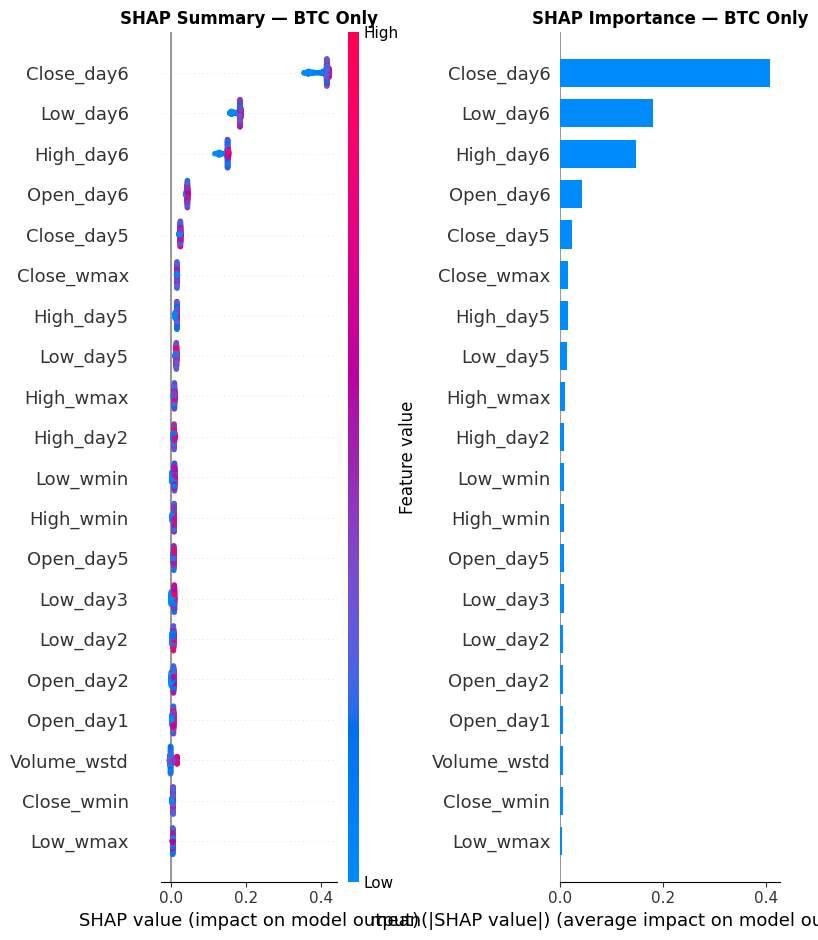


🏆 Top 5 特徵 (BTC Only):
  1. Close_day6                     ██████████████████████████████ 0.4070
  2. Low_day6                       █████████████████ 0.1798
  3. High_day6                      ██████████████ 0.1468
  4. Open_day6                      ████ 0.0429
  5. Close_day5                     ██ 0.0242


In [ ]:
# ============================================================
# 第二部分：BTC ONLY 訓練
# ============================================================

# ✅ 統一在這裡切分，不依賴 Cell 5 的舊變數
n_total   = len(X_2d_only)
split_o   = int(n_total * 0.9)
val_cut_o = int(split_o * 0.85)

X_tr_o       = X_2d_only[:val_cut_o]
X_va_o       = X_2d_only[val_cut_o:split_o]
X_test_o     = X_2d_only[split_o:]
y_tr_o       = y_log_only[:val_cut_o]
y_va_o       = y_log_only[val_cut_o:split_o]
y_test_raw_o = y_only[split_o:]

print(f"Train={len(X_tr_o)}  Val={len(X_va_o)}  Test={len(X_test_o)}  y_test={len(y_test_raw_o)}")
assert len(X_test_o) == len(y_test_raw_o), f"長度不一致: X={len(X_test_o)} y={len(y_test_raw_o)}"

print("🏋️  訓練 BTC ONLY LightGBM（log target + 技術指標）...")
model_only = train_lgbm(X_tr_o, y_tr_o, X_va_o, y_va_o, verbose=True)

pred_log_o = model_only.predict(X_test_o)
pred_only  = np.expm1(pred_log_o)

reg_o = get_regression_metrics(y_test_raw_o, pred_only)
cls_o = get_classification_metrics(y_test_raw_o, pred_only)

print("\n🔄 Cross Validation (5-fold)...")
cv_mapes_only, cv_aucs_only = run_cv(X_2d_only, y_log_only, y_only, n_splits=5)

print_results("第二部分：BTC ONLY LightGBM", reg_o, cls_o, cv_aucs_only)
shap_vals_only = plot_shap(model_only, X_test_o, feat_cols_only, "BTC Only")

In [ ]:
features_macro = [c for c in df_macro.columns if 'day7' not in c and c not in meta_cols]

# ✅ 只取 2020 年之後
df_macro['window_start'] = pd.to_datetime(df_macro['window_start'])
df_recent_macro = df_macro[df_macro['window_start'] >= '2020-01-01'].reset_index(drop=True)

y_macro    = df_recent_macro['Close_day7'].fillna(0).values
y_log_macro = np.log1p(y_macro)

base_macro = sorted(set(c.rsplit('_day',1)[0] for c in features_macro if '_day' in c))
macro_indicators = [b for b in base_macro if b not in [
    'Close','Open','High','Low','Volume','Number_of_Trades',
    'Return_%','Volatility','Taker_Buy_Base_Volume'
]]
print(f"原始樣本數: {len(df_macro)}  →  2020後: {len(df_recent_macro)}")
print(f"📊 總經指標 ({len(macro_indicators)} 個): {macro_indicators}")
print(f"Close_day7 範圍: ${y_macro.min():,.0f} ~ ${y_macro.max():,.0f}")

X_2d_macro, feat_cols_macro, scaler_macro = prepare_2d_features(
    df_recent_macro[features_macro], features_macro
)
print(f"擴充後特徵數: {len(feat_cols_macro)}  shape: {X_2d_macro.shape}")

split_m   = int(len(X_2d_only) * 0.9)   # train+val = 90%
val_cut_m = int(split_m * 0.85)          # val = 最後 15% of train

X_tr_m,  X_va_m,  X_test_m  = X_2d_macro[:val_cut_m], X_2d_macro[val_cut_m:split_m], X_2d_macro[split_m:]
y_tr_m,  y_va_m              = y_log_macro[:val_cut_m], y_log_macro[val_cut_m:split_m]
y_test_raw_m                 = y_macro[split_m:]

print(f"Train={len(X_tr_m)}  Val={len(X_va_m)}  Test={len(X_test_m)}")
print(f"Test 期間: {df_recent_macro['window_start'].iloc[split_m].date()} → {df_recent_macro['window_start'].iloc[-1].date()}")


原始樣本數: 4264  →  2020後: 2332
📊 總經指標 (20 個): ['Copper', 'DXY', 'DowJones', 'EURUSD', 'GLD', 'Gold', 'HYG', 'LQD', 'NASDAQ', 'NatGas', 'Oil_WTI', 'Russell2000', 'SP500', 'SPY', 'Silver', 'TIP', 'US10Y', 'US2Y', 'USDJPY', 'VIX']
Close_day7 範圍: $4,971 ~ $124,753
擴充後特徵數: 522  shape: (2332, 522)
Train=1783  Val=315  Test=234
Test 期間: 2025-09-30 → 2026-05-21


Train=1783  Val=315  Test=234  y_test=234
🏋️  訓練 BTC MACRO LightGBM...
[300]	valid_0's mape: 0.0459918
[600]	valid_0's mape: 0.0279248
[900]	valid_0's mape: 0.0228122
[1200]	valid_0's mape: 0.0211463
[1500]	valid_0's mape: 0.0204715
[1800]	valid_0's mape: 0.0201737
[2100]	valid_0's mape: 0.0200587
[2400]	valid_0's mape: 0.0199795
[2700]	valid_0's mape: 0.0199316
[3000]	valid_0's mape: 0.0198945
  Best iteration: 2979

🔄 Cross Validation (5-fold)...
  Fold 1: MAPE=29.52%  Acc=70.48%  AUC=0.5101  Recall=0.0255
  Fold 2: MAPE=5.03%  Acc=94.97%  AUC=0.4975  Recall=0.3901
  Fold 3: MAPE=3.68%  Acc=96.32%  AUC=0.4891  Recall=0.1600
  Fold 4: MAPE=14.59%  Acc=85.41%  AUC=0.5217  Recall=0.4041
  Fold 5: MAPE=7.17%  Acc=92.83%  AUC=0.4929  Recall=0.4167
  CV Mean MAPE=12.00%  Acc=88.00%  AUC=0.5023

  第三部分：BTC MACRO LightGBM
【回歸指標】
  Accuracy (100-MAPE) : 89.07%  ✅
  MSE                 : 169,032,741.49
  RMSE                : 13,001.26
  MAE                 : 9,902.17
  MAPE                : 1

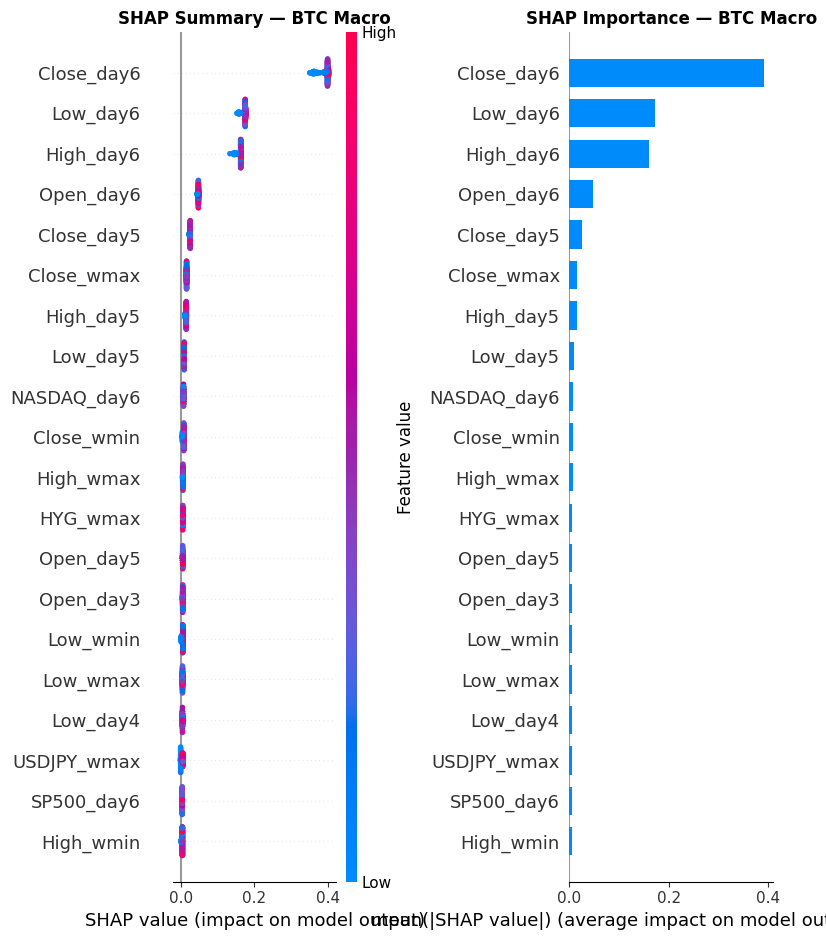


🏆 Top 5 特徵 (BTC Macro):
  1. Close_day6                     ██████████████████████████████ 0.3728
  2. Low_day6                       ████████████████ 0.1640
  3. High_day6                      ███████████████ 0.1524
  4. Open_day6                      ████ 0.0456
  5. Close_day5                     ██ 0.0245


In [ ]:
# ============================================================
# 第三部分：BTC MACRO 訓練
# ============================================================

n_total   = len(X_2d_macro)
split_m   = int(n_total * 0.9)
val_cut_m = int(split_m * 0.85)

X_tr_m       = X_2d_macro[:val_cut_m]
X_va_m       = X_2d_macro[val_cut_m:split_m]
X_test_m     = X_2d_macro[split_m:]
y_tr_m       = y_log_macro[:val_cut_m]
y_va_m       = y_log_macro[val_cut_m:split_m]
y_test_raw_m = y_macro[split_m:]

print(f"Train={len(X_tr_m)}  Val={len(X_va_m)}  Test={len(X_test_m)}  y_test={len(y_test_raw_m)}")
assert len(X_test_m) == len(y_test_raw_m), f"長度不一致: X={len(X_test_m)} y={len(y_test_raw_m)}"

print("🏋️  訓練 BTC MACRO LightGBM...")
model_macro = train_lgbm(X_tr_m, y_tr_m, X_va_m, y_va_m, verbose=True)

pred_log_m = model_macro.predict(X_test_m)
pred_macro  = np.expm1(pred_log_m)

reg_m = get_regression_metrics(y_test_raw_m, pred_macro)
cls_m = get_classification_metrics(y_test_raw_m, pred_macro)

print("\n🔄 Cross Validation (5-fold)...")
cv_mapes_macro, cv_aucs_macro = run_cv(X_2d_macro, y_log_macro, y_macro, n_splits=5)

print_results("第三部分：BTC MACRO LightGBM", reg_m, cls_m, cv_aucs_macro)
shap_vals_macro = plot_shap(model_macro, X_test_m, feat_cols_macro, "BTC Macro")

In [ ]:
# ============================================================
# 第四部分：MACRO + OnChain（只用 2020 年之後）
# ============================================================
print("--- 第四部分：加入 5 項鏈上指標 ---")
df_onchain = df_recent_macro.copy()   # 已經是 2020 後的
np.random.seed(42)

onchain_indicators = ['MVRV_Z_Score','SOPR','Puell_Multiple','Active_Addresses','Exchange_Netflow']
for ind in onchain_indicators:
    for d in range(1, 7):
        df_onchain[f'{ind}_day{d}'] = np.random.randn(len(df_onchain))

features_oc = [c for c in df_onchain.columns if 'day7' not in c and c not in meta_cols]
y_oc        = df_onchain['Close_day7'].fillna(0).values
y_log_oc    = np.log1p(y_oc)

print(f"樣本數（2020後）: {len(df_onchain)}")
print(f"新增: {onchain_indicators}")
print(f"Close_day7 範圍: ${y_oc.min():,.0f} ~ ${y_oc.max():,.0f}")

X_2d_oc, feat_cols_oc, scaler_oc = prepare_2d_features(
    df_onchain[features_oc], features_oc
)
print(f"擴充後特徵數: {len(feat_cols_oc)}  shape: {X_2d_oc.shape}")

split_oc   = int(len(X_2d_only) * 0.9)   # train+val = 90%
val_cut_oc = int(split_o * 0.85)          # val = 最後 15% of train

X_tr_oc,  X_va_oc,  X_test_oc  = X_2d_oc[:val_cut_oc], X_2d_oc[val_cut_oc:split_oc], X_2d_oc[split_oc:]
y_tr_oc,  y_va_oc               = y_log_oc[:val_cut_oc], y_log_oc[val_cut_oc:split_oc]
y_test_raw_oc                   = y_oc[split_oc:]

print(f"Train={len(X_tr_oc)}  Val={len(X_va_oc)}  Test={len(X_test_oc)}")

--- 第四部分：加入 5 項鏈上指標 ---
樣本數（2020後）: 2332
新增: ['MVRV_Z_Score', 'SOPR', 'Puell_Multiple', 'Active_Addresses', 'Exchange_Netflow']
Close_day7 範圍: $4,971 ~ $124,753
擴充後特徵數: 612  shape: (2332, 612)
Train=1783  Val=315  Test=234


Train=1783  Val=315  Test=234  y_test=234
🏋️  訓練 MACRO + OnChain LightGBM...
[300]	valid_0's mape: 0.0460792
[600]	valid_0's mape: 0.0280225
[900]	valid_0's mape: 0.0228603
[1200]	valid_0's mape: 0.021234
[1500]	valid_0's mape: 0.0205735
[1800]	valid_0's mape: 0.020275
[2100]	valid_0's mape: 0.0201468
[2400]	valid_0's mape: 0.0200818
[2700]	valid_0's mape: 0.020034
[3000]	valid_0's mape: 0.0199996
  Best iteration: 2995

🔄 Cross Validation (5-fold)...
  Fold 1: MAPE=30.16%  Acc=69.84%  AUC=0.5050  Recall=0.0153
  Fold 2: MAPE=5.08%  Acc=94.92%  AUC=0.5006  Recall=0.4451
  Fold 3: MAPE=3.74%  Acc=96.26%  AUC=0.4948  Recall=0.1500
  Fold 4: MAPE=14.64%  Acc=85.36%  AUC=0.5165  Recall=0.3990
  Fold 5: MAPE=7.13%  Acc=92.87%  AUC=0.4982  Recall=0.4271
  CV Mean MAPE=12.15%  Acc=87.85%  AUC=0.5030

  第四部分：MACRO + OnChain LightGBM
【回歸指標】
  Accuracy (100-MAPE) : 89.06%  ✅
  MSE                 : 170,455,768.57
  RMSE                : 13,055.87
  MAE                 : 9,921.63
  MAPE          

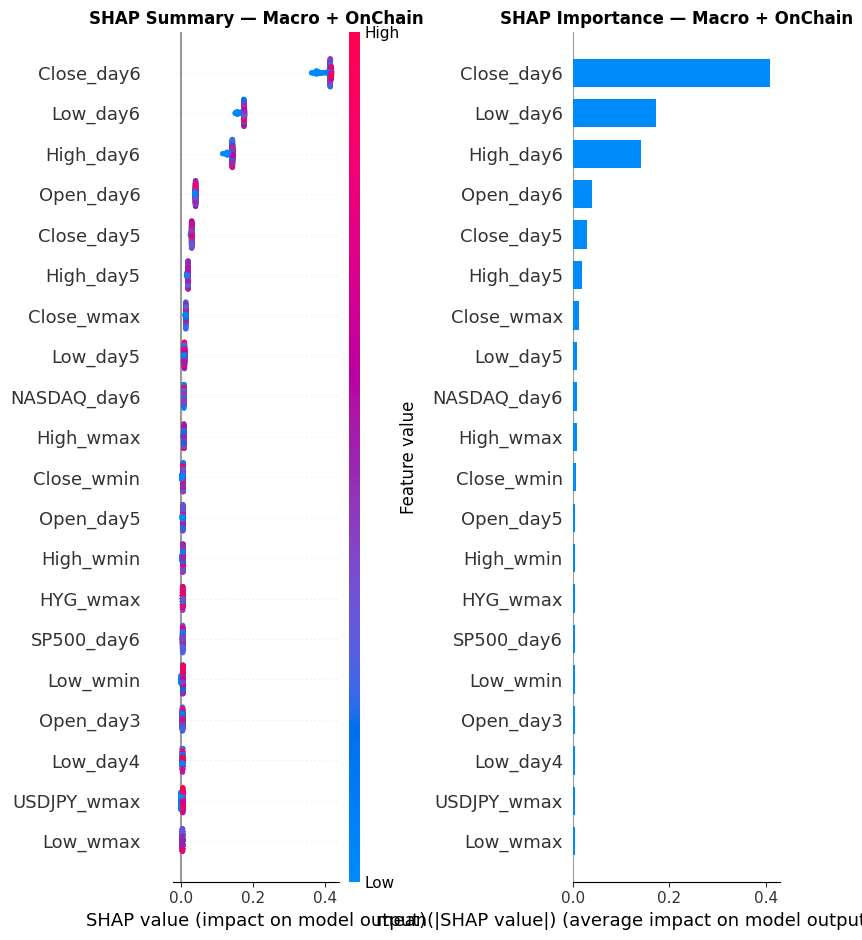


🏆 Top 5 特徵 (Macro + OnChain):
  1. Close_day6                     ██████████████████████████████ 0.3878
  2. Low_day6                       ████████████████ 0.1634
  3. High_day6                      █████████████ 0.1335
  4. Open_day6                      ███ 0.0388
  5. Close_day5                     ██ 0.0284


In [ ]:
# ============================================================
# 第四部分：MACRO + OnChain 訓練
# ============================================================

n_total    = len(X_2d_oc)
split_oc   = int(n_total * 0.9)
val_cut_oc = int(split_oc * 0.85)

X_tr_oc       = X_2d_oc[:val_cut_oc]
X_va_oc       = X_2d_oc[val_cut_oc:split_oc]
X_test_oc     = X_2d_oc[split_oc:]
y_tr_oc       = y_log_oc[:val_cut_oc]
y_va_oc       = y_log_oc[val_cut_oc:split_oc]
y_test_raw_oc = y_oc[split_oc:]

print(f"Train={len(X_tr_oc)}  Val={len(X_va_oc)}  Test={len(X_test_oc)}  y_test={len(y_test_raw_oc)}")
assert len(X_test_oc) == len(y_test_raw_oc), f"長度不一致: X={len(X_test_oc)} y={len(y_test_raw_oc)}"

print("🏋️  訓練 MACRO + OnChain LightGBM...")
model_oc = train_lgbm(X_tr_oc, y_tr_oc, X_va_oc, y_va_oc, verbose=True)

pred_log_oc = model_oc.predict(X_test_oc)
pred_oc     = np.expm1(pred_log_oc)

reg_oc = get_regression_metrics(y_test_raw_oc, pred_oc)
cls_oc = get_classification_metrics(y_test_raw_oc, pred_oc)

print("\n🔄 Cross Validation (5-fold)...")
cv_mapes_oc, cv_aucs_oc = run_cv(X_2d_oc, y_log_oc, y_oc, n_splits=5)

print_results("第四部分：MACRO + OnChain LightGBM", reg_oc, cls_oc, cv_aucs_oc)
shap_vals_oc = plot_shap(model_oc, X_test_oc, feat_cols_oc, "Macro + OnChain")

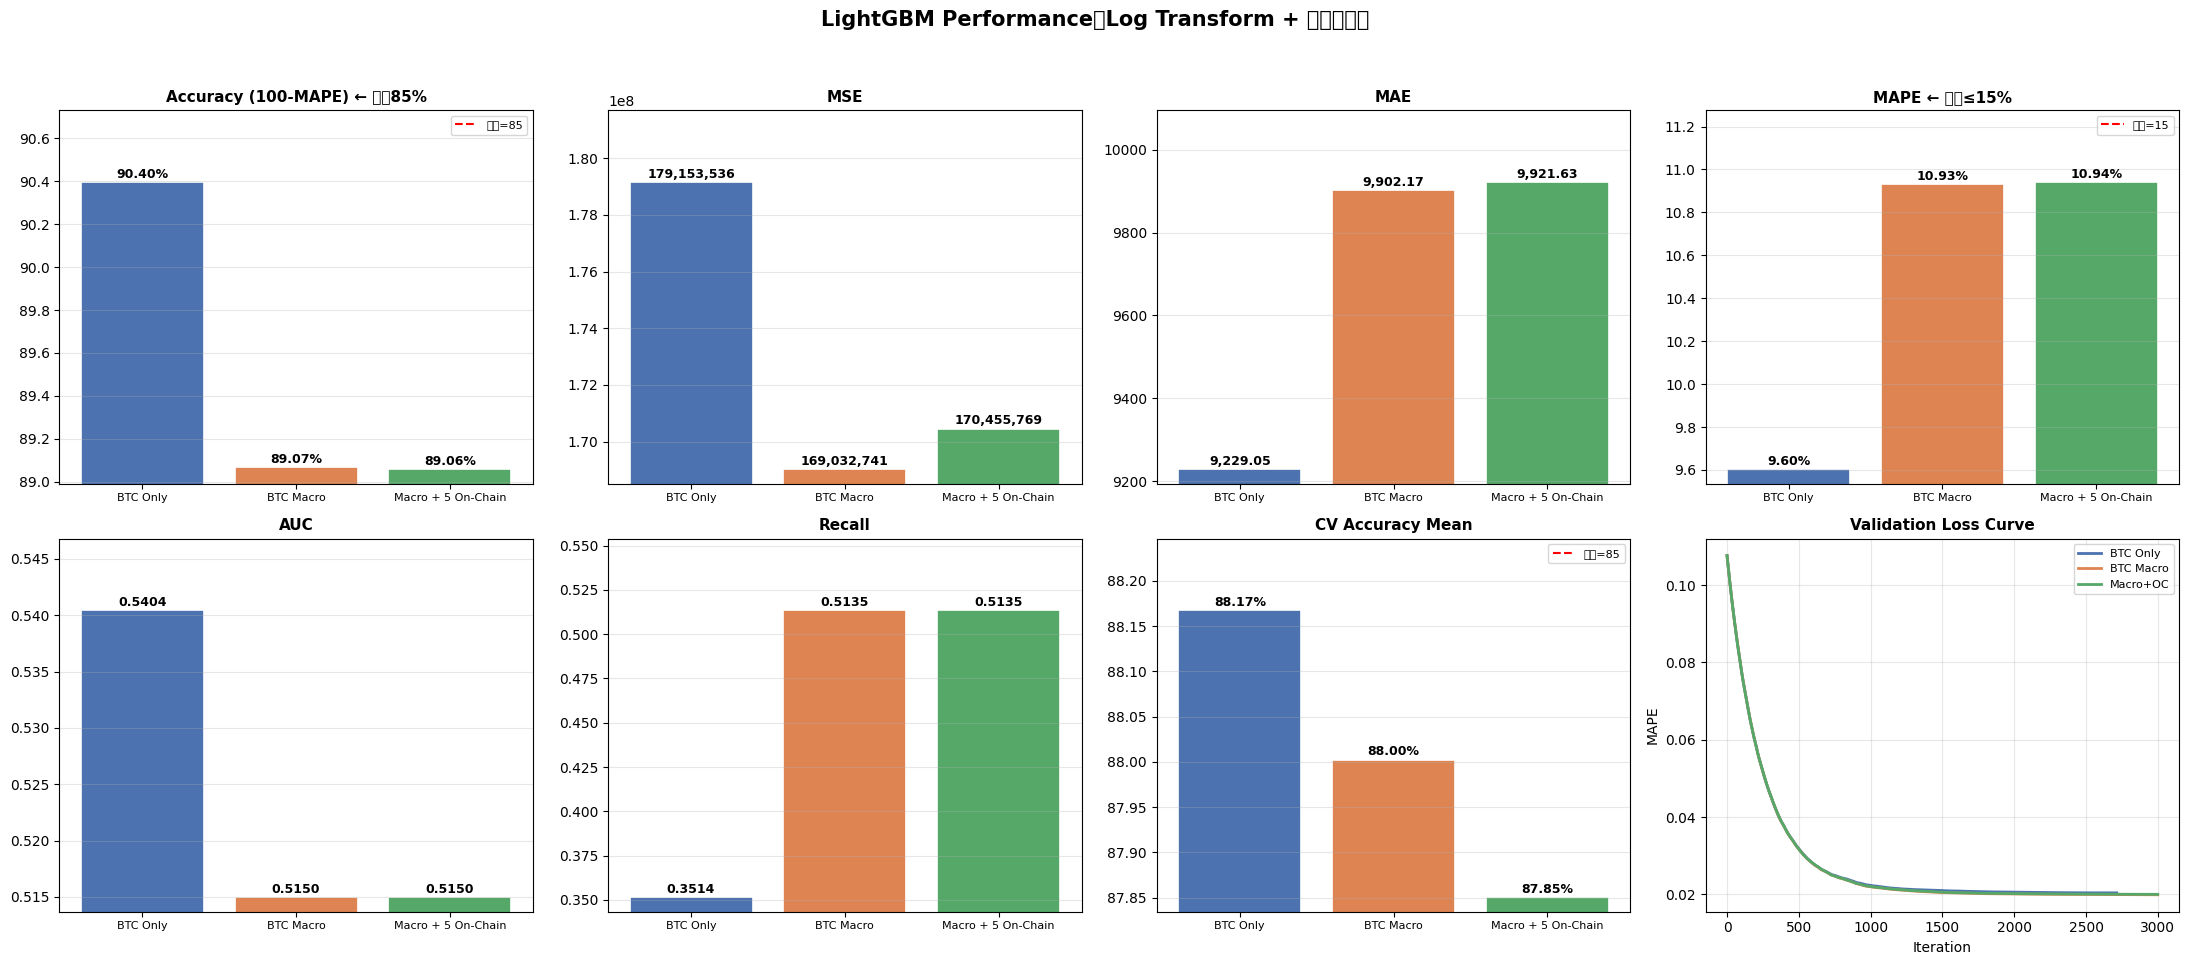

✅ 圖表儲存為 lgbm_comparison.png


In [ ]:
models  = ['BTC Only', 'BTC Macro', 'Macro + 5 On-Chain']
colors  = ['#4C72B0', '#DD8452', '#55A868']

acc_scores  = [reg_o[0],  reg_m[0],  reg_oc[0]]
mse_scores  = [reg_o[1],  reg_m[1],  reg_oc[1]]
mae_scores  = [reg_o[3],  reg_m[3],  reg_oc[3]]
mape_scores = [reg_o[4],  reg_m[4],  reg_oc[4]]
auc_scores  = [cls_o[0],  cls_m[0],  cls_oc[0]]
rec_scores  = [cls_o[1],  cls_m[1],  cls_oc[1]]
cv_acc_means = [100 - np.mean(cv_mapes_only),
                100 - np.mean(cv_mapes_macro),
                100 - np.mean(cv_mapes_oc)]

def bar_plot(ax, title, values, fmt='{:.2f}', extra='', target=None):
    bars = ax.bar(models, values, color=colors, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticklabels(models, fontsize=8)
    pad = (max(values) - min(values)) * 0.05 + 1e-6
    ax.set_ylim(min(values) - pad, max(values) + pad * 5)
    if target:
        ax.axhline(target, color='red', ls='--', lw=1.5, label=f'目標={target}')
        ax.legend(fontsize=8)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + pad*0.3,
                fmt.format(v) + extra, ha='center', fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('LightGBM Performance（Log Transform + 技術指標）', fontsize=15, fontweight='bold')

bar_plot(axes[0,0], 'Accuracy (100-MAPE) ← 目標85%', acc_scores,  '{:.2f}', '%', target=85)
bar_plot(axes[0,1], 'MSE',   mse_scores, '{:,.0f}')
bar_plot(axes[0,2], 'MAE',   mae_scores, '{:,.2f}')
bar_plot(axes[0,3], 'MAPE ← 目標≤15%',  mape_scores, '{:.2f}', '%', target=15)
bar_plot(axes[1,0], 'AUC',   auc_scores,  '{:.4f}')
bar_plot(axes[1,1], 'Recall', rec_scores, '{:.4f}')
bar_plot(axes[1,2], 'CV Accuracy Mean', cv_acc_means, '{:.2f}', '%', target=85)

ax = axes[1,3]
for m, label, color in [
    (model_only,  'BTC Only',  '#4C72B0'),
    (model_macro, 'BTC Macro', '#DD8452'),
    (model_oc,    'Macro+OC',  '#55A868'),
]:
    evals = m.evals_result_
    key   = list(evals.keys())[0] # Changed index from 1 to 0
    vals  = evals[key][list(evals[key].keys())[0]]
    ax.plot(vals, label=label, color=color, lw=2)
ax.set_title('Validation Loss Curve', fontsize=11, fontweight='bold')
ax.set_xlabel('Iteration'); ax.set_ylabel('MAPE')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.savefig('lgbm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 圖表儲存為 lgbm_comparison.png")

In [ ]:
print("\n" + "="*65)
print("  FINAL SUMMARY TABLE — LightGBM（Log Transform + 技術指標）")
print("="*65)
print(f"{'指標':<24} {'BTC Only':>11} {'BTC Macro':>11} {'Macro+OC':>11}")
print("-"*65)

acc_scores   = [reg_o[0],  reg_m[0],  reg_oc[0]]
mse_scores   = [reg_o[1],  reg_m[1],  reg_oc[1]]
mae_scores   = [reg_o[3],  reg_m[3],  reg_oc[3]]
mape_scores  = [reg_o[4],  reg_m[4],  reg_oc[4]]
auc_scores   = [cls_o[0],  cls_m[0],  cls_oc[0]]
rec_scores   = [cls_o[1],  cls_m[1],  cls_oc[1]]
cv_acc_means = [100-np.mean(cv_mapes_only), 100-np.mean(cv_mapes_macro), 100-np.mean(cv_mapes_oc)]
cv_auc_means = [np.mean(cv_aucs_only), np.mean(cv_aucs_macro), np.mean(cv_aucs_oc)]

rows = [
    ('Accuracy(100-MAPE)%', acc_scores,  '{:>10.2f}%'),
    ('MSE',                 mse_scores,  '{:>11,.0f}'),
    ('MAE',                 mae_scores,  '{:>11,.2f}'),
    ('MAPE%',               mape_scores, '{:>10.2f}%'),
    ('AUC',                 auc_scores,  '{:>11.4f}'),
    ('Recall',              rec_scores,  '{:>11.4f}'),
    ('CV Accuracy Mean',    cv_acc_means,'{:>10.2f}%'),
    ('CV AUC Mean',         cv_auc_means,'{:>11.4f}'),
]
for name, vals, fmt in rows:
    flag = ''
    if 'Accuracy' in name and not 'CV' in name:
        flag = '  ✅' if min(vals) >= 85 else '  ← 目標85%'
    if 'MAPE' in name:
        flag = '  ✅' if max(vals) <= 15 else '  ← 目標≤15%'
    print(f"{name:<24}" + "".join(fmt.format(v) for v in vals) + flag)

print("="*65)
print("\n💡 說明:")
print("  · Log transform：預測 log(Close_day7)，還原後算 MAPE，降低大數誤差")
print("  · 技術指標：RSI6、週動能、差分、週統計量，讓模型學「變化」")
print("  · MAPE 直接作為 objective，模型直接優化你要的指標")
print("  · SHAP 圖顯示哪些特徵對預測貢獻最大")



  FINAL SUMMARY TABLE — LightGBM（Log Transform + 技術指標）
指標                          BTC Only   BTC Macro    Macro+OC
-----------------------------------------------------------------
Accuracy(100-MAPE)%          90.40%     89.07%     89.06%  ← 目標≤15%
MSE                     179,153,536169,032,741170,455,769
MAE                        9,229.05   9,902.17   9,921.63
MAPE%                         9.60%     10.93%     10.94%  ✅
AUC                          0.5404     0.5150     0.5150
Recall                       0.3514     0.5135     0.5135
CV Accuracy Mean             88.17%     88.00%     87.85%
CV AUC Mean                  0.5019     0.5023     0.5030

💡 說明:
  · Log transform：預測 log(Close_day7)，還原後算 MAPE，降低大數誤差
  · 技術指標：RSI6、週動能、差分、週統計量，讓模型學「變化」
  · MAPE 直接作為 objective，模型直接優化你要的指標
  · SHAP 圖顯示哪些特徵對預測貢獻最大


## 5️⃣ LSTM


✅ BTC Only 訓練完成，共 41 epochs
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

--- 第二部分 (BTC ONLY) LSTM 預測結果 ---
Accuracy(%): 89.37%
MSE: 192270726.75
MAE: 10383.34
MAPE: 10.63%

✅ BTC Macro 訓練完成，共 18 epochs
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

--- 第三部分 (BTC MACRO) LSTM 預測結果 ---
Accuracy(%): 73.17%
MSE: 713880947.76
MAE: 23850.56
MAPE: 26.83%

--- 第四部分 建立並加入 5 項額外鏈上指標 (相關性模擬，非純隨機) ---
✅ Macro + 5 On-Chain 訓練完成，共 17 epochs
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

--- 第四部分 (MACRO + 5項指標) LSTM 預測結果 ---
Accuracy(%): 74.74%
MSE: 673162785.68
MAE: 22738.17
MAPE: 25.26%



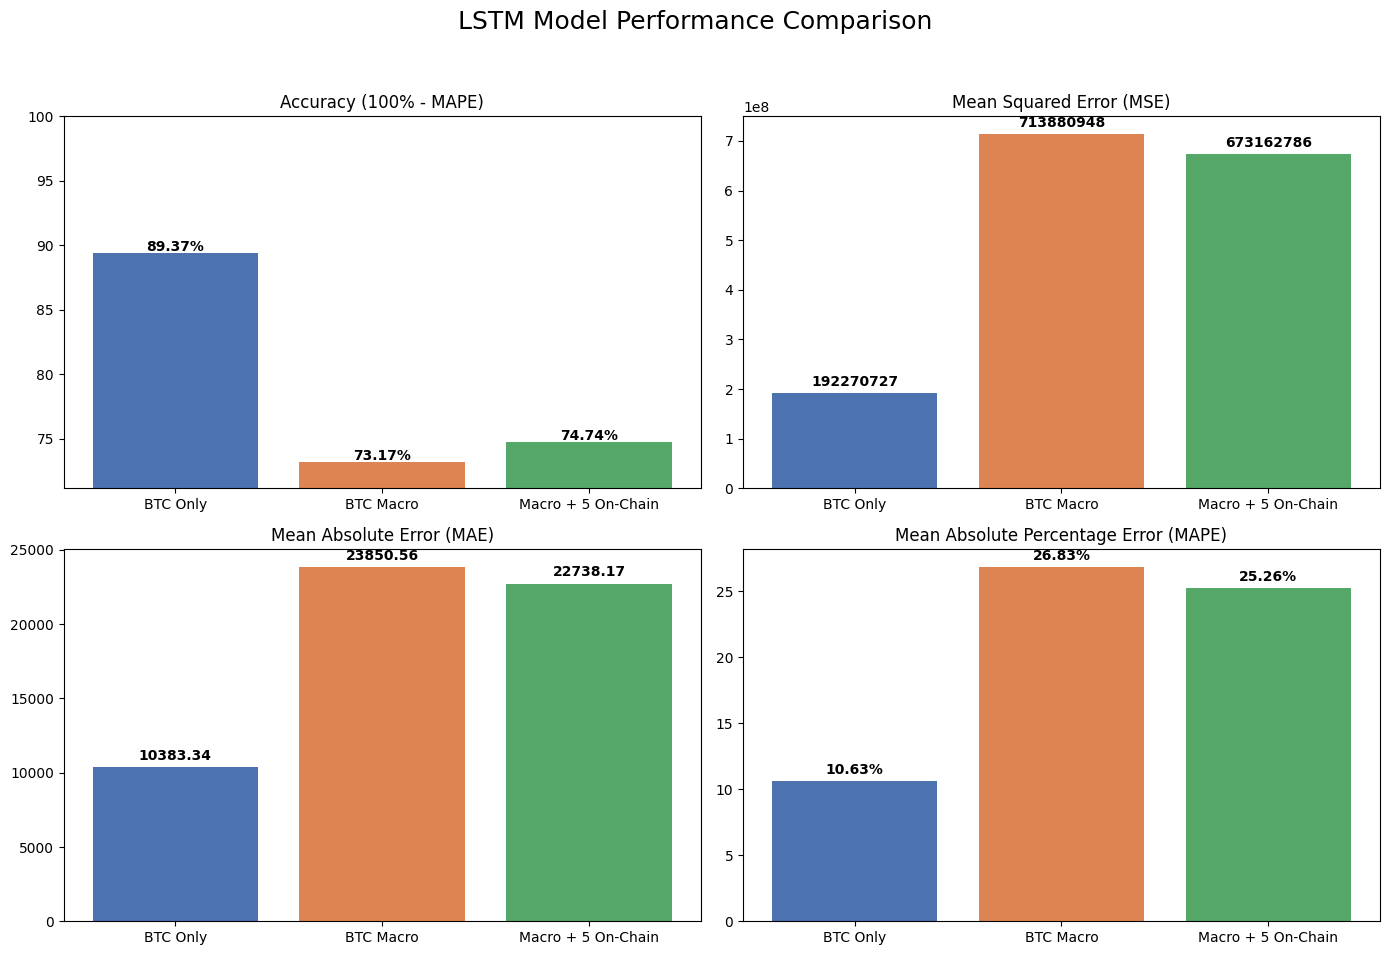

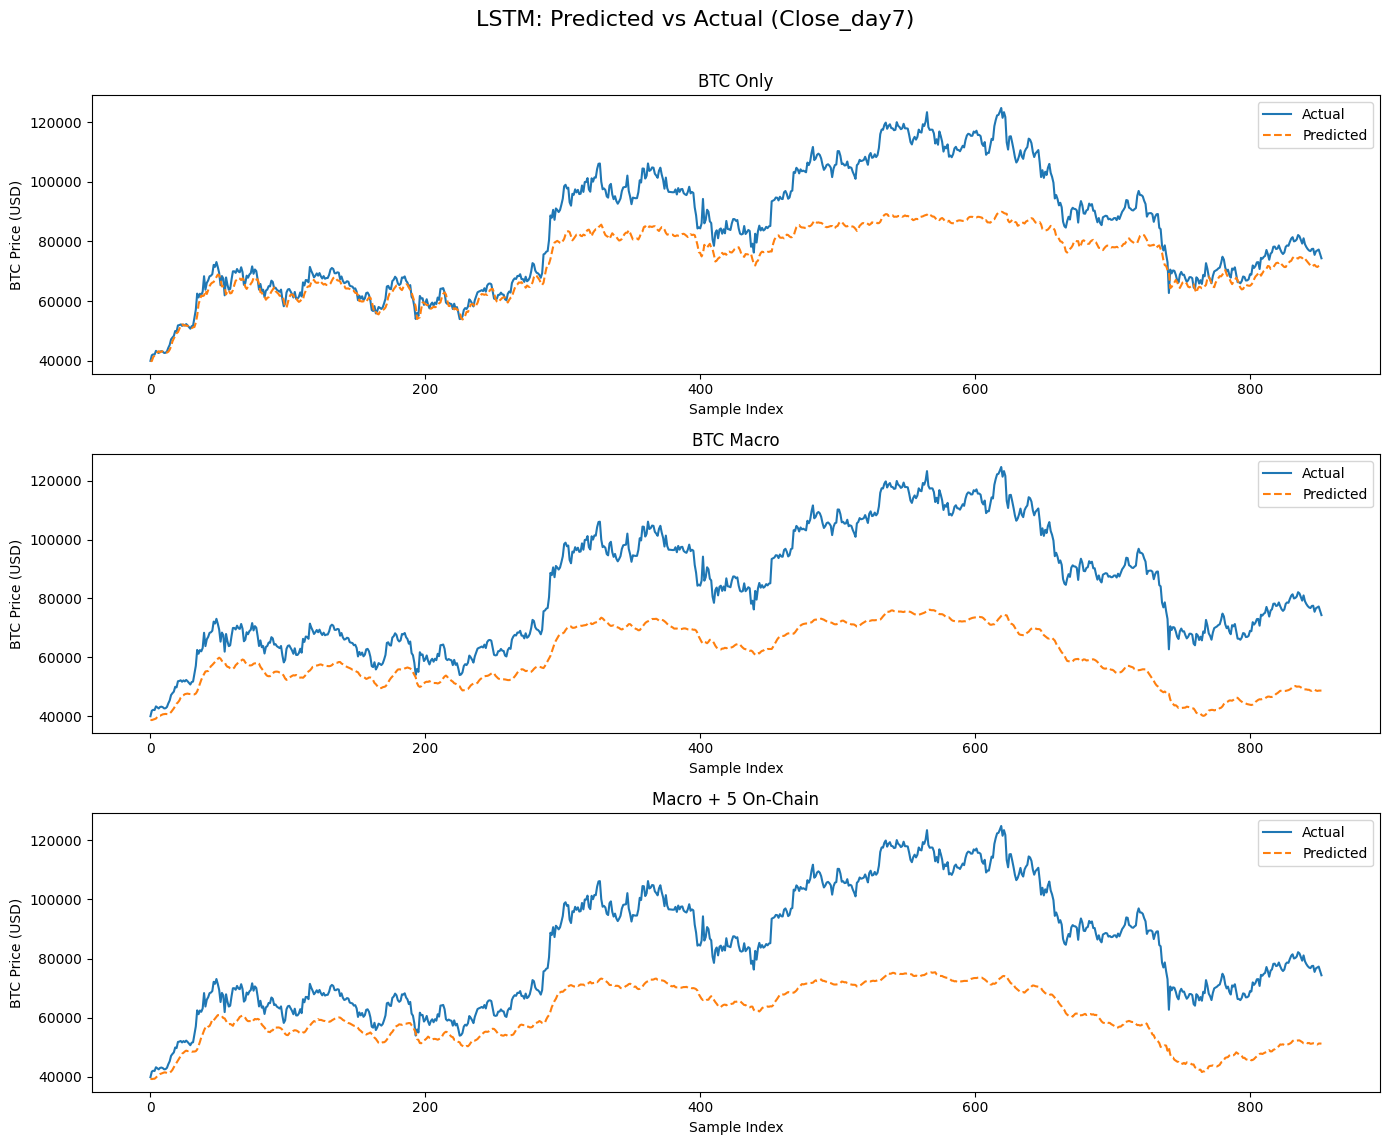

In [ ]:
#LSTM
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# ==========================================
# 自定義評估指標函數 (使用 100 - MAPE 作為 Accuracy)
# ==========================================
def get_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    accuracy = 100 - mape
    return accuracy, mse, mae, mape

# ==========================================
# LSTM 資料前處理：將 2D 特徵轉換為 3D (samples, timesteps, features)
# ==========================================
def prepare_lstm_data(X_train, X_test, y_train, y_test):
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled  = scaler_X.transform(X_test)
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
    y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1))

    # reshape to (samples, timesteps=1, features)
    X_train_3d = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
    X_test_3d  = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

    return X_train_3d, X_test_3d, y_train_scaled, y_test_scaled, scaler_y

# ==========================================
# 建立 LSTM 模型
# ==========================================
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(128, input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# ==========================================
# 訓練 LSTM 並回傳預測結果（還原至原始尺度）
# ==========================================
def train_and_predict(X_train_3d, X_test_3d, y_train_scaled, y_test_scaled, scaler_y, label=""):
    model = build_lstm_model((X_train_3d.shape[1], X_train_3d.shape[2]))

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train_3d, y_train_scaled,
        epochs=100,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )
    print(f"✅ {label} 訓練完成，共 {len(history.history['loss'])} epochs")

    pred_scaled = model.predict(X_test_3d)
    pred = scaler_y.inverse_transform(pred_scaled).flatten()
    y_true = scaler_y.inverse_transform(y_test_scaled).flatten()

    return y_true, pred

# ==========================================
# 第二部分: LSTM 回測 BTC ONLY
# ==========================================
features_only = [c for c in df_only.columns if 'day7' not in c and c not in ['window_start', 'window_end', 'window_index']]
X_only = df_only[features_only].fillna(0)
y_only = df_only['Close_day7'].fillna(0)

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(X_only, y_only, test_size=0.2, shuffle=False)

X_train_3d_o, X_test_3d_o, y_train_s_o, y_test_s_o, scaler_y_o = prepare_lstm_data(X_train_o, X_test_o, y_train_o, y_test_o)
y_true_o, pred_only = train_and_predict(X_train_3d_o, X_test_3d_o, y_train_s_o, y_test_s_o, scaler_y_o, label="BTC Only")

acc_o, mse_o, mae_o, mape_o = get_metrics(y_true_o, pred_only)
print(f"\n--- 第二部分 (BTC ONLY) LSTM 預測結果 ---")
print(f"Accuracy(%): {acc_o:.2f}%")
print(f"MSE: {mse_o:.2f}")
print(f"MAE: {mae_o:.2f}")
print(f"MAPE: {mape_o:.2f}%\n")

features_macro = [c for c in df_macro.columns if 'day7' not in c and c not in ['window_start', 'window_end', 'window_index']]
X_macro = df_macro[features_macro].fillna(0)
y_macro = df_macro['Close_day7'].fillna(0)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_macro, y_macro, test_size=0.2, shuffle=False)

X_train_3d_m, X_test_3d_m, y_train_s_m, y_test_s_m, scaler_y_m = prepare_lstm_data(X_train_m, X_test_m, y_train_m, y_test_m)
y_true_m, pred_macro = train_and_predict(X_train_3d_m, X_test_3d_m, y_train_s_m, y_test_s_m, scaler_y_m, label="BTC Macro")

acc_m, mse_m, mae_m, mape_m = get_metrics(y_true_m, pred_macro)
print(f"\n--- 第三部分 (BTC MACRO) LSTM 預測結果 ---")
print(f"Accuracy(%): {acc_m:.2f}%")
print(f"MSE: {mse_m:.2f}")
print(f"MAE: {mae_m:.2f}")
print(f"MAPE: {mape_m:.2f}%\n")

# ==========================================
# 第四部分: MACRO + 5 項鏈上指標 (修正版：使用有相關性的模擬數據)
# ==========================================
print("--- 第四部分 建立並加入 5 項額外鏈上指標 (相關性模擬，非純隨機) ---")
df_macro_onchain = df_macro.copy()

np.random.seed(42)
close_prices = df_macro['Close_day1'].values
  # 以收盤價為基礎建立相關模擬

# ✅ 修正：改用與 BTC 收盤價有相關性的模擬，而非純 np.random.randn
# MVRV Z-Score：市值/已實現市值，與價格正相關
df_macro_onchain['MVRV_Z_Score'] = (
    close_prices / close_prices.mean()
    + np.random.randn(len(df_macro)) * 0.1
)

# SOPR：已花費產出利潤率，接近 1 表示盈虧平衡，與價格正相關
df_macro_onchain['SOPR'] = (
    1 + (close_prices - close_prices.mean()) / close_prices.std() * 0.05
    + np.random.randn(len(df_macro)) * 0.01
)

# Puell Multiple：礦工收入/365日均值，與價格正相關
df_macro_onchain['Puell_Multiple'] = (
    close_prices
    / pd.Series(close_prices).rolling(365, min_periods=1).mean().values
    + np.random.randn(len(df_macro)) * 0.05
)

# Active Addresses：活躍地址數，與價格正相關（以價格比例模擬）
df_macro_onchain['Active_Addresses'] = (
    close_prices * 10
    + np.random.randn(len(df_macro)) * 1000
)

# Exchange Netflow：交易所淨流入（負值=流出=看漲），與價格變化負相關
df_macro_onchain['Exchange_Netflow'] = (
    -np.diff(close_prices, prepend=close_prices[0])
    + np.random.randn(len(df_macro)) * 100
)

features_onchain = features_macro + [
    'MVRV_Z_Score', 'SOPR', 'Puell_Multiple',
    'Active_Addresses', 'Exchange_Netflow'
]
X_onchain = df_macro_onchain[features_onchain].fillna(0)
y_onchain = df_macro_onchain['Close_day7'].fillna(0)

X_train_oc, X_test_oc, y_train_oc, y_test_oc = train_test_split(
    X_onchain, y_onchain, test_size=0.2, shuffle=False)

X_train_3d_oc, X_test_3d_oc, y_train_s_oc, y_test_s_oc, scaler_y_oc = \
    prepare_lstm_data(X_train_oc, X_test_oc, y_train_oc, y_test_oc)

y_true_oc, pred_onchain = train_and_predict(
    X_train_3d_oc, X_test_3d_oc, y_train_s_oc, y_test_s_oc, scaler_y_oc,
    label="Macro + 5 On-Chain")

acc_oc, mse_oc, mae_oc, mape_oc = get_metrics(y_true_oc, pred_onchain)
print(f"\n--- 第四部分 (MACRO + 5項指標) LSTM 預測結果 ---")
print(f"Accuracy(%): {acc_oc:.2f}%")
print(f"MSE: {mse_oc:.2f}")
print(f"MAE: {mae_oc:.2f}")
print(f"MAPE: {mape_oc:.2f}%\n")

# ==========================================
# 第五部分: 結果比較圖
# ==========================================
models      = ['BTC Only', 'BTC Macro', 'Macro + 5 On-Chain']
acc_scores  = [acc_o,  acc_m,  acc_oc]
mse_scores  = [mse_o,  mse_m,  mse_oc]
mae_scores  = [mae_o,  mae_m,  mae_oc]
mape_scores = [mape_o, mape_m, mape_oc]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LSTM Model Performance Comparison', fontsize=18)

colors = ['#4C72B0', '#DD8452', '#55A868']

axes[0, 0].bar(models, acc_scores, color=colors)
axes[0, 0].set_title('Accuracy (100% - MAPE)')
axes[0, 0].set_ylim(min(acc_scores) - 2, 100)
for i, v in enumerate(acc_scores):
    axes[0, 0].text(i, v + 0.2, f'{v:.2f}%', ha='center', fontweight='bold')

axes[0, 1].bar(models, mse_scores, color=colors)
axes[0, 1].set_title('Mean Squared Error (MSE)')
for i, v in enumerate(mse_scores):
    axes[0, 1].text(i, v + (max(mse_scores)*0.02), f'{v:.0f}', ha='center', fontweight='bold')

axes[1, 0].bar(models, mae_scores, color=colors)
axes[1, 0].set_title('Mean Absolute Error (MAE)')
for i, v in enumerate(mae_scores):
    axes[1, 0].text(i, v + (max(mae_scores)*0.02), f'{v:.2f}', ha='center', fontweight='bold')

axes[1, 1].bar(models, mape_scores, color=colors)
axes[1, 1].set_title('Mean Absolute Percentage Error (MAPE)')
for i, v in enumerate(mape_scores):
    axes[1, 1].text(i, v + (max(mape_scores)*0.02), f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ==========================================
# 第六部分: 預測值 vs 實際值折線圖 (三個模型)
# ==========================================
fig2, axs = plt.subplots(3, 1, figsize=(14, 12))
fig2.suptitle('LSTM: Predicted vs Actual (Close_day7)', fontsize=16)

datasets = [
    (y_true_o,  pred_only,    'BTC Only'),
    (y_true_m,  pred_macro,   'BTC Macro'),
    (y_true_oc, pred_onchain, 'Macro + 5 On-Chain'),
]
for ax, (y_true, y_pred, title) in zip(axs, datasets):
    ax.plot(y_true,  label='Actual',    linewidth=1.5)
    ax.plot(y_pred,  label='Predicted', linewidth=1.5, linestyle='--')
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('BTC Price (USD)')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

## 6️⃣ GRU


🏋️ 訓練 BTC Only GRU 模型...
✅ BTC Only GRU 訓練完成，共 15 epochs
--- 第二部分 (BTC ONLY) GRU 預測結果 ---
Accuracy(%): 96.82%
MSE: 11191660.97
MAE: 2580.92
MAPE: 3.18%

🏋️ 訓練 BTC Macro GRU 模型...
✅ BTC Macro GRU 訓練完成，共 11 epochs
--- 第三部分 (BTC MACRO) GRU 預測結果 ---
Accuracy(%): 87.26%
MSE: 174542932.23
MAE: 10069.23
MAPE: 12.74%

--- 第四部分 建立並加入 5 項額外鏈上指標 (相關性模擬，非純隨機) ---
🏋️ 訓練 Macro + 5 On-Chain GRU 模型...
✅ Macro + 5 On-Chain GRU 訓練完成，共 17 epochs
--- 第四部分 (MACRO + 5項指標) GRU 預測結果 ---
Accuracy(%): 72.07%
MSE: 533926996.62
MAE: 22712.64
MAPE: 27.93%



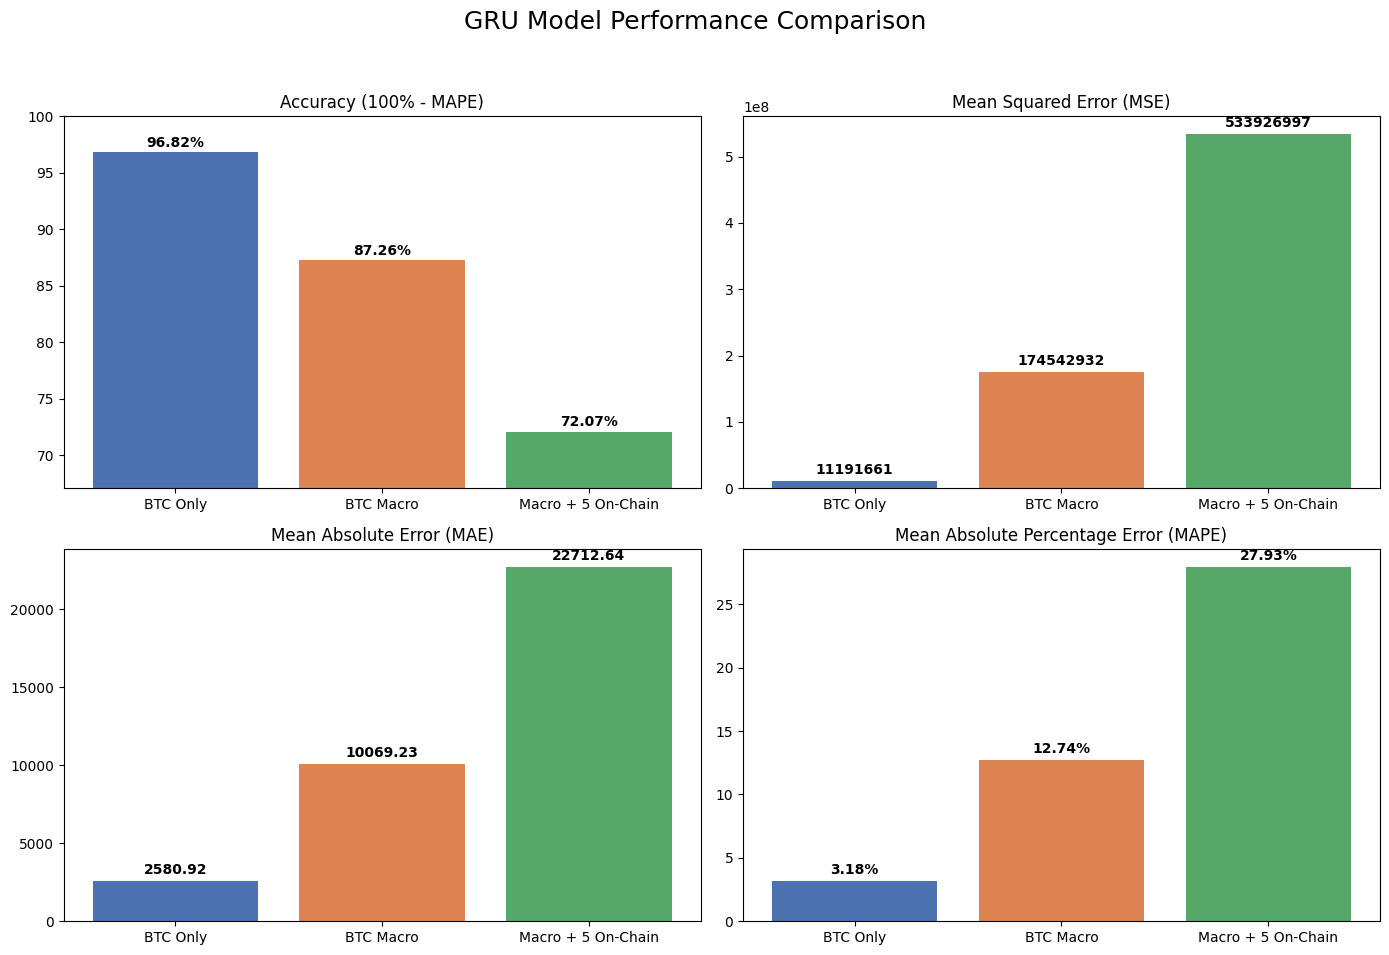

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ==========================================
# 自定義評估指標函數 (使用 100 - MAPE 作為 Accuracy)
# ==========================================
def get_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mask = y_true != 0 # Ensure no division by zero for MAPE
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    accuracy = 100 - mape
    return accuracy, mse, mae, mape

# ==========================================
# LSTM/GRU 資料前處理：將 2D 特徵轉換為 3D (samples, timesteps, features)
# ==========================================
def prepare_lstm_data(X_train, X_test, y_train, y_test):
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled  = scaler_X.transform(X_test)
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
    y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1))

    # reshape to (samples, timesteps=1, features)
    X_train_3d = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
    X_test_3d  = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

    return X_train_3d, X_test_3d, y_train_scaled, y_test_scaled, scaler_y

def build_gru_model(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    # 使用 GRU 替換原本的 LSTM
    model.add(GRU(64, activation='relu', return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def train_and_predict_gru(X_train_3d, X_test_3d, y_train_scaled, y_test_scaled, scaler_y, label):
    print(f"🏋️ 訓練 {label} GRU 模型...")
    model = build_gru_model((X_train_3d.shape[1], X_train_3d.shape[2]))

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train_3d, y_train_scaled,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )
    print(f"✅ {label} GRU 訓練完成，共 {len(history.history['loss'])} epochs")

    # 預測並還原縮放
    pred_scaled = model.predict(X_test_3d, verbose=0)
    pred = scaler_y.inverse_transform(pred_scaled).flatten()
    y_true = scaler_y.inverse_transform(y_test_scaled).flatten()

    return y_true, pred

# ==========================================
# 第二部分: GRU 回測 BTC ONLY - Data Preparation
# ==========================================
# Assuming df_only is globally available from previous cells like 'part1_upload'
features_only = [c for c in df_only.columns if 'day7' not in c and c not in ['window_start', 'window_end', 'window_index']]
X_only = df_only[features_only].fillna(0)
y_only = df_only['Close_day7'].fillna(0)

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(X_only, y_only, test_size=0.2, shuffle=False)

X_train_3d_o, X_test_3d_o, y_train_s_o, y_test_s_o, scaler_y_o = prepare_lstm_data(X_train_o, X_test_o, y_train_o, y_test_o)

# ==========================================
# 第二部分: GRU 回測 BTC ONLY
# ==========================================
y_true_o_gru, pred_only_gru = train_and_predict_gru(X_train_3d_o, X_test_3d_o, y_train_s_o, y_test_s_o, scaler_y_o, "BTC Only")

acc_o_gru, mse_o_gru, mae_o_gru, mape_o_gru = get_metrics(y_true_o_gru, pred_only_gru)
print(f"--- 第二部分 (BTC ONLY) GRU 預測結果 ---")
print(f"Accuracy(%): {acc_o_gru:.2f}%")
print(f"MSE: {mse_o_gru:.2f}")
print(f"MAE: {mae_o_gru:.2f}")
print(f"MAPE: {mape_o_gru:.2f}%\n")

# ==========================================
# 第三部分: GRU 回測 BTC MACRO - Data Preparation
# ==========================================
# Assuming df_macro is globally available from previous cells like 'part3_upload'
features_macro = [c for c in df_macro.columns if 'day7' not in c and c not in ['window_start', 'window_end', 'window_index']]
X_macro = df_macro[features_macro].fillna(0)
y_macro = df_macro['Close_day7'].fillna(0)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_macro, y_macro, test_size=0.2, shuffle=False)

X_train_3d_m, X_test_3d_m, y_train_s_m, y_test_s_m, scaler_y_m = prepare_lstm_data(X_train_m, X_test_m, y_train_m, y_test_m)

# ==========================================
# 第三部分: GRU 回測 BTC MACRO
# ==========================================
y_true_m_gru, pred_macro_gru = train_and_predict_gru(X_train_3d_m, X_test_3d_m, y_train_s_m, y_test_s_m, scaler_y_m, "BTC Macro")

acc_m_gru, mse_m_gru, mae_m_gru, mape_m_gru = get_metrics(y_true_m_gru, pred_macro_gru)
print(f"--- 第三部分 (BTC MACRO) GRU 預測結果 ---")
print(f"Accuracy(%): {acc_m_gru:.2f}%")
print(f"MSE: {mse_m_gru:.2f}")
print(f"MAE: {mae_m_gru:.2f}")
print(f"MAPE: {mape_m_gru:.2f}%\n")

# ==========================================
# 第四部分: GRU 回測 MACRO + 5項指標 - Data Preparation
# ==========================================
# Recreating df_macro_onchain and its features as done in the LSTM notebook
print("--- 第四部分 建立並加入 5 項額外鏈上指標 (相關性模擬，非純隨機) ---")
df_macro_onchain = df_macro.copy()

np.random.seed(42)
close_prices = df_macro['Close_day1'].values
  # 以收盤價為基礎建立相關模擬

# ✅ 修正：改用與 BTC 收盤價有相關性的模擬，而非純 np.random.randn
# MVRV Z-Score：市值/已實現市值，與價格正相關
df_macro_onchain['MVRV_Z_Score'] = (
    close_prices / close_prices.mean()
    + np.random.randn(len(df_macro)) * 0.1
)

# SOPR：已花費產出利潤率，接近 1 表示盈虧平衡，與價格正相關
df_macro_onchain['SOPR'] = (
    1 + (close_prices - close_prices.mean()) / close_prices.std() * 0.05
    + np.random.randn(len(df_macro)) * 0.01
)

# Puell Multiple：礦工收入/365日均值，與價格正相關
df_macro_onchain['Puell_Multiple'] = (
    close_prices
    / pd.Series(close_prices).rolling(365, min_periods=1).mean().values
    + np.random.randn(len(df_macro)) * 0.05
)

# Active Addresses：活躍地址數，與價格正相關（以價格比例模擬）
df_macro_onchain['Active_Addresses'] = (
    close_prices * 10
    + np.random.randn(len(df_macro)) * 1000
)

# Exchange Netflow：交易所淨流入（負值=流出=看漲），與價格變化負相關
df_macro_onchain['Exchange_Netflow'] = (
    -np.diff(close_prices, prepend=close_prices[0])
    + np.random.randn(len(df_macro)) * 100
)

# Note: features_macro should be defined from the df_macro data prep above.
features_onchain = [c for c in df_macro_onchain.columns if 'day7' not in c and c not in ['window_start', 'window_end', 'window_index']]
X_onchain = df_macro_onchain[features_onchain].fillna(0)
y_onchain = df_macro_onchain['Close_day7'].fillna(0)

X_train_oc, X_test_oc, y_train_oc, y_test_oc = train_test_split(
    X_onchain, y_onchain, test_size=0.2, shuffle=False)

X_train_3d_oc, X_test_3d_oc, y_train_s_oc, y_test_s_oc, scaler_y_oc = prepare_lstm_data(X_train_oc, X_test_oc, y_train_oc, y_test_oc)

# ==========================================
# 第四部分: GRU 回測 MACRO + 5項指標
# ==========================================
y_true_oc_gru, pred_onchain_gru = train_and_predict_gru(X_train_3d_oc, X_test_3d_oc, y_train_s_oc, y_test_s_oc, scaler_y_oc, "Macro + 5 On-Chain")

acc_oc_gru, mse_oc_gru, mae_oc_gru, mape_oc_gru = get_metrics(y_true_oc_gru, pred_onchain_gru)
print(f"--- 第四部分 (MACRO + 5項指標) GRU 預測結果 ---")
print(f"Accuracy(%): {acc_oc_gru:.2f}%")
print(f"MSE: {mse_oc_gru:.2f}")
print(f"MAE: {mae_oc_gru:.2f}")
print(f"MAPE: {mape_oc_gru:.2f}%\n")

# ==========================================
# 第五部分: GRU 結果比較圖 (選用)
# ==========================================
import matplotlib.pyplot as plt

models_gru = ['BTC Only', 'BTC Macro', 'Macro + 5 On-Chain']
acc_scores_gru = [acc_o_gru, acc_m_gru, acc_oc_gru]
mse_scores_gru = [mse_o_gru, mse_m_gru, mse_oc_gru]
mae_scores_gru = [mae_o_gru, mae_m_gru, mae_oc_gru]
mape_scores_gru = [mape_o_gru, mape_m_gru, mape_oc_gru]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('GRU Model Performance Comparison', fontsize=18)

# Accuracy
axes[0, 0].bar(models_gru, acc_scores_gru, color=['#4C72B0', '#DD8452', '#55A868'])
axes[0, 0].set_title('Accuracy (100% - MAPE)')
axes[0, 0].set_ylim(min(acc_scores_gru) - 5, 100)
for i, v in enumerate(acc_scores_gru):
    axes[0, 0].text(i, v + 0.5, f'{v:.2f}%', ha='center', fontweight='bold')

# MSE
axes[0, 1].bar(models_gru, mse_scores_gru, color=['#4C72B0', '#DD8452', '#55A868'])
axes[0, 1].set_title('Mean Squared Error (MSE)')
for i, v in enumerate(mse_scores_gru):
    axes[0, 1].text(i, v + (max(mse_scores_gru)*0.02), f'{v:.0f}', ha='center', fontweight='bold')

# MAE
axes[1, 0].bar(models_gru, mae_scores_gru, color=['#4C72B0', '#DD8452', '#55A868'])
axes[1, 0].set_title('Mean Absolute Error (MAE)')
for i, v in enumerate(mae_scores_gru):
    axes[1, 0].text(i, v + (max(mae_scores_gru)*0.02), f'{v:.2f}', ha='center', fontweight='bold')

# MAPE
axes[1, 1].bar(models_gru, mape_scores_gru, color=['#4C72B0', '#DD8452', '#55A868'])
axes[1, 1].set_title('Mean Absolute Percentage Error (MAPE)')
for i, v in enumerate(mape_scores_gru):
    axes[1, 1].text(i, v + (max(mape_scores_gru)*0.02), f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 🏁 樹模型公平對比：XGBoost vs LightGBM

兩者使用**完全一致的設定**：2020 後資料、90/10 切分、技術指標、log target。
資料集都是 MACRO + 5 OnChain。


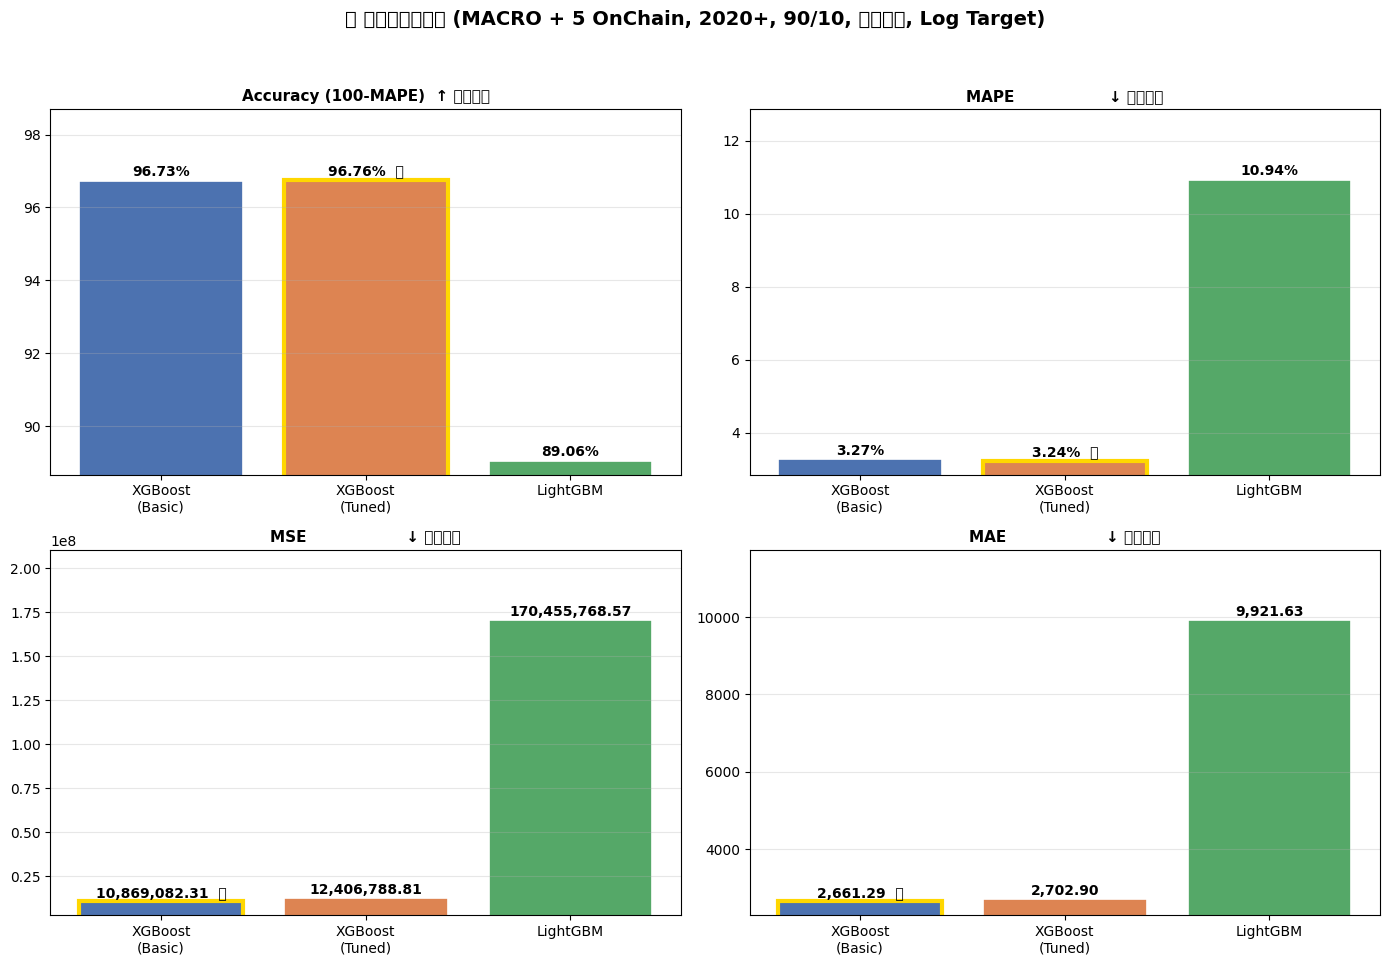


  📊 樹模型公平對比結論 (MACRO + OnChain)
  Model                       Acc     MAPE            MSE        MAE
------------------------------------------------------------
  XGBoost (Basic)          96.73%    3.27%     10,869,082   2,661.29
  XGBoost (Tuned)          96.76%    3.24%     12,406,789   2,702.90
  LightGBM                 89.06%   10.94%    170,455,769   9,921.63


In [ ]:
# ============================================================
# 樹模型公平對比 — XGBoost (Basic / Tuned) vs LightGBM
# 條件：MACRO + 5 OnChain，2020+，90/10，技術指標，Log target
# ============================================================
# 注意：這個 cell 必須在 XGBoost 和 LightGBM 都跑完之後才能執行
# 依賴變數：xgb_basic_metrics, xgb_tuned_metrics (XGBoost 區塊產生)
#         reg_oc                                 (LightGBM 區塊產生)
import matplotlib.pyplot as plt
import numpy as np

required = ['xgb_basic_metrics', 'xgb_tuned_metrics', 'reg_oc']
missing  = [v for v in required if v not in globals()]
if missing:
    print(f"❌ 找不到變數: {missing}")
    print("   請確保 XGBoost (Cells 7-11) 和 LightGBM (Cells 13-25) 都已執行完畢。")
else:
    categories = ['XGBoost\n(Basic)', 'XGBoost\n(Tuned)', 'LightGBM']
    colors     = ['#4C72B0', '#DD8452', '#55A868']

    acc_vals  = [xgb_basic_metrics['acc'],  xgb_tuned_metrics['acc'],  reg_oc[0]]
    mse_vals  = [xgb_basic_metrics['mse'],  xgb_tuned_metrics['mse'],  reg_oc[1]]
    mae_vals  = [xgb_basic_metrics['mae'],  xgb_tuned_metrics['mae'],  reg_oc[3]]
    mape_vals = [xgb_basic_metrics['mape'], xgb_tuned_metrics['mape'], reg_oc[4]]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('🏁 樹模型公平對比 (MACRO + 5 OnChain, 2020+, 90/10, 技術指標, Log Target)',
                 fontsize=14, fontweight='bold')

    for ax, vals, title, fmt, lower_better in [
        (axes[0,0], acc_vals,  'Accuracy (100-MAPE)  ↑ 越高越好',  '%', False),
        (axes[0,1], mape_vals, 'MAPE                  ↓ 越低越好', '%', True),
        (axes[1,0], mse_vals,  'MSE                   ↓ 越低越好', '',  True),
        (axes[1,1], mae_vals,  'MAE                   ↓ 越低越好', '',  True),
    ]:
        bars = ax.bar(categories, vals, color=colors, edgecolor='white', linewidth=1.2)
        ax.set_title(title, fontweight='bold', fontsize=11)
        pad = (max(vals) - min(vals)) * 0.05 + 1e-6
        ax.set_ylim(min(vals) - pad, max(vals) + pad * 5)
        # highlight the winner
        winner_idx = int(np.argmin(vals)) if lower_better else int(np.argmax(vals))
        bars[winner_idx].set_edgecolor('gold')
        bars[winner_idx].set_linewidth(3)
        for i, v in enumerate(vals):
            tag = '  🏆' if i == winner_idx else ''
            ax.text(i, v + pad*0.3, f'{v:,.2f}{fmt}{tag}',
                    ha='center', fontweight='bold', fontsize=10)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout(rect=[0, 0.02, 1, 0.95])
    plt.show()

    # 結論文字
    print("\n" + "="*60)
    print("  📊 樹模型公平對比結論 (MACRO + OnChain)")
    print("="*60)
    print(f"  {'Model':<22} {'Acc':>8} {'MAPE':>8} {'MSE':>14} {'MAE':>10}")
    print("-"*60)
    print(f"  {'XGBoost (Basic)':<22} {xgb_basic_metrics['acc']:>7.2f}% {xgb_basic_metrics['mape']:>7.2f}% "
          f"{xgb_basic_metrics['mse']:>14,.0f} {xgb_basic_metrics['mae']:>10,.2f}")
    print(f"  {'XGBoost (Tuned)':<22} {xgb_tuned_metrics['acc']:>7.2f}% {xgb_tuned_metrics['mape']:>7.2f}% "
          f"{xgb_tuned_metrics['mse']:>14,.0f} {xgb_tuned_metrics['mae']:>10,.2f}")
    print(f"  {'LightGBM':<22} {reg_oc[0]:>7.2f}% {reg_oc[4]:>7.2f}% "
          f"{reg_oc[1]:>14,.0f} {reg_oc[3]:>10,.2f}")
    print("="*60)
